

## Algeria Export Opportunity — Clustering Notebook
**ENSIA — Machine Learning Project, Spring 2025-2026**
## Context
This notebook follows directly from `algeria_trade_analysis.ipynb` (EDA notebook).
That notebook already:
- Loaded and cleaned `world_trade_data_enriched.csv`
- Engineered all trade features
- Applied StandardScaler + PCA (21 features → 16 principal components, 90% variance)
- Saved the result as `world_trade_data_pca.csv`

**This notebook starts from `world_trade_data_pca.csv` — no preprocessing needed.**

## Structure of `world_trade_data_pca.csv`
| Columns | Description |
|---|---|
| `PC1` to `PC16` | PCA components (already standardized) |
| `year` | 2012 to 2024 |
| `importer` | Country code (97 countries) |
| `product` | HS4 product code (1,224 products) |
| `sector` | Sector name (17 sectors) |
| `algeria_present` | 1 if Algeria exported this product to this country this year |
| `opportunity_label` | 0=Low, 1=Medium, 2=High (for reference/validation only) |

## What this notebook does
1. Load `world_trade_data_pca.csv`
2. Build country-level and product-level aggregated PCA matrices
3. Cap PC values at ±3 std dev (as specified in EDA next steps)
4. Country clustering: Elbow + Silhouette → K-Means → DBSCAN validation
5. Product clustering: Elbow + Silhouette → K-Means → DBSCAN validation  
6. Full evaluation: Silhouette Score + Davies-Bouldin Index per the project spec
7. Cluster profiling and economic interpretation
8. Attach cluster labels back to the main dataset and export

## Input
`data/world_trade_data_pca.csv`

## Outputs
- `data/world_trade_data_clustered.csv` — PCA file + cluster labels
- `models/kmeans_countries.pkl`
- `models/kmeans_products.pkl`
- `outputs/country_cluster_profiles.csv`
- `outputs/product_cluster_profiles.csv`


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
import pickle

from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# ── Paths ──────────────────────────────────────────────────────────────────────
PCA_FILE       = '../data/world_trade_data_pca.csv'
CLUSTERED_FILE = '../data/world_trade_data_clustered.csv'
MODELS_DIR     = '../models'
OUTPUTS_DIR    = '../outputs'

os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

# Colors used consistently across all plots
CLUSTER_COLORS = [
    '#3a7abf', '#1d9e75', '#d64e4e', '#e09c3b',
    '#9b59b6', '#e67e22', '#1abc9c',"#d33ce7",
    "#293fb9", "#030c07"
]
LABEL_COLORS = {0: '#d64e4e', 1: '#e09c3b', 2: '#1d9e75'}
LABEL_MAP    = {0: 'Low', 1: 'Medium', 2: 'High'}

print("Setup complete.")

Setup complete.


---
## 1. Load `world_trade_data_pca.csv`

This file was produced by the EDA notebook. It contains the PCA-transformed feature matrix
alongside the key identifiers. We do NOT redo any preprocessing or PCA here.


In [36]:
df_pca = pd.read_csv(PCA_FILE, dtype={'product': str})
df_pca['product'] = df_pca['product'].str.zfill(4)

# Identify the PC columns automatically
PC_COLS = [c for c in df_pca.columns if c.startswith('PC')]

print(f"Dataset shape    : {df_pca.shape}")
print(f"PC columns       : {PC_COLS}  ({len(PC_COLS)} components)")
print(f"Years            : {sorted(df_pca['year'].unique())}")
print(f"Importers        : {df_pca['importer'].nunique()}")
print(f"Products         : {df_pca['product'].nunique()}")
print(f"Sectors          : {df_pca['sector'].nunique()}")
print(f"Algeria present  : {df_pca['algeria_present'].sum():,} rows ({100*df_pca['algeria_present'].mean():.1f}%)")
print()
print("Opportunity label distribution (reference only — NOT used in clustering):")
for k, v in df_pca['opportunity_label'].value_counts().sort_index().items():
    print(f"  {LABEL_MAP[k]:8} ({k}): {v:,}  ({100*v/len(df_pca):.1f}%)")
print()
print("First 3 rows:")
print(df_pca[PC_COLS + ['year','importer','product','sector']].head(3).to_string())

Dataset shape    : (1501178, 22)
PC columns       : ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16']  (16 components)
Years            : [np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Importers        : 97
Products         : 1224
Sectors          : 17
Algeria present  : 45,292 rows (3.0%)

Opportunity label distribution (reference only — NOT used in clustering):
  Low      (0): 345,998  (23.0%)
  Medium   (1): 838,681  (55.9%)
  High     (2): 316,499  (21.1%)

First 3 rows:
      PC1     PC2     PC3     PC4     PC5    PC6    PC7     PC8     PC9    PC10   PC11    PC12   PC13    PC14   PC15    PC16  year  importer product              sector
0 -0.8849 -0.3263 -0.3841 -0.2819  0.3630 0.4357 0.2908 -0.6392 -0.0644 -0.0172 0.0452 -0.0647 0.4002 -0.1197 0.9847 -0

---
## 2. Build aggregated matrices

The PCA file has one row per `(year, importer, product)` — 1.5M rows total.
K-Means needs one row per **entity** we want to cluster.

We aggregate by taking the **mean** of all PC values across all years and products
(for country clustering) or across all years and importers (for product clustering).

This gives us a stable "fingerprint" for each country and each product.

> **Why mean?** Because we want to capture the typical trade behavior of each entity
> over the full 2012–2024 period, not just one year.


### 2.1 Country-level matrix — one row per importer

In [37]:
# Average all PC components across all (year, product) for each importer
country_matrix = (
    df_pca.groupby('importer')[PC_COLS]
    .mean()
    .reset_index()
)

# Attach continent for later interpretation (take the most frequent value)
continent_map = (
    df_pca[['importer','sector']]   # we use sector as proxy; continent not in pca file
    .drop_duplicates('importer')
    .rename(columns={'sector': 'top_sector'})
)
country_matrix = country_matrix.merge(continent_map, on='importer', how='left')

# Also attach: how many unique products does Algeria export to this importer?
alg_presence = (
    df_pca[df_pca['algeria_present'] == 1]
    .groupby('importer')
    .agg(algeria_product_count=('product','nunique'))
    .reset_index()
)
country_matrix = country_matrix.merge(alg_presence, on='importer', how='left')
country_matrix['algeria_product_count'] = country_matrix['algeria_product_count'].fillna(0)

print(f"Country matrix shape: {country_matrix.shape}")
print(f"  ({country_matrix['importer'].nunique()} importers × {len(PC_COLS)} PC columns + metadata)")
print()
print(country_matrix[PC_COLS].describe().T[['mean','std','min','max']].round(3))

Country matrix shape: (97, 19)
  (97 importers × 16 PC columns + metadata)

        mean    std     min    max
PC1   0.0010 1.6980 -1.7680 6.8690
PC2  -0.0140 1.3270 -1.6410 6.6350
PC3  -0.0170 1.3520 -4.3150 5.0920
PC4   0.0040 0.3500 -2.0910 0.8450
PC5  -0.0060 0.9530 -5.4700 2.4660
PC6  -0.0010 0.6650 -1.6910 2.5930
PC7   0.0040 0.6180 -2.3340 2.8280
PC8   0.0020 0.6610 -2.9770 2.3960
PC9  -0.0010 0.8070 -1.8060 1.8100
PC10 -0.0020 0.4480 -1.2930 2.5160
PC11  0.0050 0.7640 -2.0760 1.7140
PC12  0.0040 0.4050 -1.8760 0.9300
PC13  0.0010 0.3530 -1.1530 0.5230
PC14  0.0040 0.7980 -1.2140 2.3640
PC15  0.0010 0.5690 -1.4230 2.6720
PC16 -0.0010 0.6470 -2.4620 3.1210


### 2.2 Product-level matrix — one row per product

In [38]:
# Average all PC components across all (year, importer) for each product
product_matrix = (
    df_pca.groupby('product')[PC_COLS]
    .mean()
    .reset_index()
)

# Attach sector (each product belongs to exactly one sector)
sector_map = df_pca[['product','sector']].drop_duplicates('product')
product_matrix = product_matrix.merge(sector_map, on='product', how='left')

# How many importers does Algeria reach for this product?
alg_reach = (
    df_pca[df_pca['algeria_present'] == 1]
    .groupby('product')
    .agg(algeria_market_count=('importer','nunique'))
    .reset_index()
)
product_matrix = product_matrix.merge(alg_reach, on='product', how='left')
product_matrix['algeria_market_count'] = product_matrix['algeria_market_count'].fillna(0)

print(f"Product matrix shape: {product_matrix.shape}")
print(f"  ({product_matrix['product'].nunique()} products × {len(PC_COLS)} PC columns + metadata)")
print()
print(product_matrix[PC_COLS].describe().T[['mean','std','min','max']].round(3))

Product matrix shape: (1224, 19)
  (1224 products × 16 PC columns + metadata)

        mean    std     min     max
PC1   0.0000 0.0330 -0.2690  0.2800
PC2  -0.0010 0.2770 -0.2330  4.4490
PC3   0.0010 0.0680 -0.1740  0.7550
PC4  -0.0140 1.1040 -0.8570 16.8200
PC5   0.0030 0.0950 -0.7670  0.7770
PC6  -0.0000 0.1640 -1.7360  2.7410
PC7   0.0080 0.2550 -0.8170  2.8250
PC8   0.0130 0.2770 -1.5050  1.3880
PC9  -0.0010 0.1470 -1.2260  2.8070
PC10 -0.0090 0.2660 -2.8650  2.5210
PC11 -0.0070 0.2630 -1.4870  2.7450
PC12 -0.0050 0.1330 -2.4110  0.1080
PC13 -0.0020 0.3760 -4.7670  1.0000
PC14 -0.0020 0.0860 -0.7960  0.2160
PC15 -0.0010 0.0840 -1.1210  0.3060
PC16  0.0000 0.2220 -2.2390  3.2600


---
## 3. Cap PC values at ±3 standard deviations


**Why:** A few extreme outliers... (e.g. USA or China with enormous GDP and import volumes)
can distort K-Means centroids. Since PCA components are already standardized (mean=0, std=1),
values beyond ±3 are genuine outliers. Clipping them prevents any single country or
product from dominating the cluster assignments.


In [39]:
# Back to original
X_country = country_matrix[PC_COLS].clip(-3, 3).values
X_product = product_matrix[PC_COLS].clip(-3, 3).values

print(f"Country matrix after clip: {X_country.shape}")
print(f"  Range: [{X_country.min():.3f}, {X_country.max():.3f}]")
print(f"  Rows clipped: {(country_matrix[PC_COLS].abs() > 3).any(axis=1).sum()}")
print()
print(f"Product matrix after clip: {X_product.shape}")
print(f"  Range: [{X_product.min():.3f}, {X_product.max():.3f}]")
print(f"  Rows clipped: {(product_matrix[PC_COLS].abs() > 3).any(axis=1).sum()}")

Country matrix after clip: (97, 16)
  Range: [-3.000, 3.000]
  Rows clipped: 11

Product matrix after clip: (1224, 16)
  Range: [-3.000, 3.000]
  Rows clipped: 17


---
## 4. Shared helper functions

Defined once, called for both country and product clustering.

### What each function does
- **`elbow_and_silhouette()`** — runs K-Means for K=3 to 10, plots inertia (elbow) and silhouette score, returns the best K
- **`fit_kmeans()`** — fits the final K-Means with the chosen K, prints Silhouette + Davies-Bouldin, returns labels
- **`run_dbscan()`** — auto-selects eps from k-NN distances, runs DBSCAN, reports clusters and noise
- **`scatter_pca()`** — 2D scatter plot of PC1 vs PC2 coloured by cluster
- **`silhouette_plot()`** — per-sample silhouette plot showing how well each point fits its cluster


In [40]:
def elbow_and_silhouette(X, label, k_range=range(3, 11)):
    """
    Run K-Means for each K in k_range.
    Plot inertia (elbow) and silhouette score.
    Return: best_k (int), sil_scores (dict)
    """
    inertias   = []
    sil_scores = []

    for k in k_range:
        km  = KMeans(n_clusters=k, random_state=42, n_init=10)
        lbl = km.fit_predict(X)
        inertias.append(km.inertia_)
        if len(set(lbl)) > 1:
            sil_scores.append(silhouette_score(X, lbl))
        else:
            sil_scores.append(0)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Elbow plot
    axes[0].plot(list(k_range), inertias, marker='o', color='#3a7abf', linewidth=2)
    axes[0].set_xlabel('Number of clusters K')
    axes[0].set_ylabel('Inertia (within-cluster sum of squares)')
    axes[0].set_title(f'{label} — Elbow method\n(look for the bend)')
    axes[0].set_xticks(list(k_range))

    # Silhouette plot
    axes[1].plot(list(k_range), sil_scores, marker='o', color='#1d9e75', linewidth=2)
    axes[1].set_xlabel('Number of clusters K')
    axes[1].set_ylabel('Silhouette score  (higher = better)')
    axes[1].set_title(f'{label} — Silhouette score\n(pick the highest)')
    axes[1].set_xticks(list(k_range))
    for k, s in zip(k_range, sil_scores):
        axes[1].annotate(f'{s:.3f}', (k, s),
                         textcoords='offset points', xytext=(0, 8),
                         ha='center', fontsize=8)

    plt.tight_layout()
    plt.show()

    best_k = list(k_range)[int(np.argmax(sil_scores))]
    best_s = max(sil_scores)
    print(f"{label}: Best K = {best_k}  (silhouette = {best_s:.4f})")

    return best_k, dict(zip(k_range, sil_scores))


def fit_kmeans(X, k, label, save_path=None):
    """
    Fit final K-Means with chosen K.
    Print Silhouette Score and Davies-Bouldin Index.
    Return: km_model, labels_array
    """
    km     = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X)

    sil = silhouette_score(X, labels)
    dbi = davies_bouldin_score(X, labels)

    print("=" * 55)
    print(f"  K-Means — {label}")
    print("=" * 55)
    print(f"  K (clusters)          : {k}")
    print(f"  Silhouette score      : {sil:.4f}  (↑ higher = better, max = 1.0)")
    print(f"  Davies-Bouldin index  : {dbi:.4f}  (↓ lower  = better, min = 0.0)")
    print()

    unique, counts = np.unique(labels, return_counts=True)
    print("  Cluster sizes:")
    for cl, cnt in zip(unique, counts):
        pct = 100 * cnt / len(labels)
        print(f"    Cluster {cl}: {cnt:>5}  ({pct:.1f}%)")

    if save_path:
        with open(save_path, 'wb') as f:
            pickle.dump(km, f)
        print(f"\n  Model saved: {save_path}")

    return km, labels, sil, dbi


def run_dbscan(X, label, min_samples=3, auto_eps_percentile=85):
    """
    1. Plot k-NN distances to help choose eps automatically.
    2. Run DBSCAN with auto-selected eps.
    3. Report number of clusters and noise points.
    4. Return labels.
    """
    # k-NN distance plot — the 'elbow' in this plot = good eps
    nbrs  = NearestNeighbors(n_neighbors=min_samples).fit(X)
    dists, _ = nbrs.kneighbors(X)
    knn_dist = np.sort(dists[:, -1])
    eps      = float(np.percentile(knn_dist, auto_eps_percentile))

    fig, ax = plt.subplots(figsize=(9, 3.5))
    ax.plot(knn_dist, color='#3a7abf', linewidth=1.2)
    ax.axhline(eps, color='#d64e4e', linewidth=1, linestyle='--',
               label=f'Auto eps = {eps:.3f}  ({auto_eps_percentile}th percentile)')
    ax.set_xlabel('Points sorted by distance')
    ax.set_ylabel(f'{min_samples}-NN distance')
    ax.set_title(f'{label} — k-NN distance plot\n'
                 f'(the "elbow" in this curve = good eps value)')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    # Run DBSCAN
    db     = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = int((labels == -1).sum())

    print(f"DBSCAN — {label}")
    print(f"  eps = {eps:.4f},  min_samples = {min_samples}")
    print(f"  Clusters found : {n_clusters}")
    print(f"  Noise points   : {n_noise}  ({100*n_noise/len(X):.1f}%)")

    if n_clusters > 1:
        mask = labels != -1
        sil  = silhouette_score(X[mask], labels[mask])
        dbi  = davies_bouldin_score(X[mask], labels[mask])
        print(f"  Silhouette (excl. noise) : {sil:.4f}")
        print(f"  Davies-Bouldin (excl. noise) : {dbi:.4f}")
    else:
        print("  Only 1 cluster found.")
        print("  → Try a larger eps (higher percentile) or smaller min_samples.")

    return labels, n_clusters, n_noise, eps


def scatter_pca(X, labels, label, highlight_noise=True):
    """2D scatter of PC1 vs PC2 coloured by cluster label."""
    fig, ax = plt.subplots(figsize=(9, 6))

    for i, cl in enumerate(sorted(set(labels))):
        mask   = labels == cl
        cname  = f'Cluster {cl}' if cl != -1 else f'Noise ({mask.sum()} pts)'
        color  = '#aaaaaa' if cl == -1 else CLUSTER_COLORS[i % len(CLUSTER_COLORS)]
        size   = 25 if cl != -1 else 10
        alpha  = 0.8 if cl != -1 else 0.4
        ax.scatter(X[mask, 0], X[mask, 1],
                   c=color, label=cname,
                   s=size, alpha=alpha, edgecolors='white', linewidths=0.2)

    ax.set_xlabel('PC1  (captures overall market size & economic weight)')
    ax.set_ylabel('PC2  (captures trade relationship with Algeria)')
    ax.set_title(f'{label} — PC1 vs PC2')
    ax.legend(fontsize=9, markerscale=1.5)
    plt.tight_layout()
    plt.show()


def silhouette_plot(X, labels, k, label):
    """
    Per-sample silhouette plot.
    Each horizontal bar = one entity (country or product).
    Width = silhouette coefficient for that entity.
    Negative values = the entity is closer to another cluster than its own.
    """
    sil_samples = silhouette_samples(X, labels)
    mean_sil    = sil_samples.mean()

    fig, ax = plt.subplots(figsize=(9, 4))
    y_lower = 0

    for cl in range(k):
        cl_vals = np.sort(sil_samples[labels == cl])
        size    = cl_vals.shape[0]
        color   = CLUSTER_COLORS[cl % len(CLUSTER_COLORS)]

        ax.fill_betweenx(np.arange(y_lower, y_lower + size),
                         0, cl_vals,
                         alpha=0.8, color=color)
        ax.text(-0.03, y_lower + size / 2, f'C{cl}', fontsize=9, fontweight='bold')
        y_lower += size + 8

    ax.axvline(mean_sil, color='red', linewidth=1.5, linestyle='--',
               label=f'Mean silhouette = {mean_sil:.3f}')
    ax.set_xlabel('Silhouette coefficient')
    ax.set_title(f'{label} — Per-entity silhouette plot\n'
                 '(wide positive bars = well-clustered, negative = misclassified)')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

print("Helper functions defined — ready.")

Helper functions defined — ready.


---
## 5. Country clustering

**Goal:** Group the 97 importer countries by their import demand pattern.

**What we expect to find:**
- A cluster of large, wealthy economies (high import volume, far from Algeria)
- A cluster of neighbouring/Arab countries (short distance, shared language)
- A cluster of fast-growing emerging markets
- One or more clusters of smaller economies

**Input:** `X_country` — shape (97, 16), already clipped at ±3.


### 5.1 Find optimal K — Elbow + Silhouette

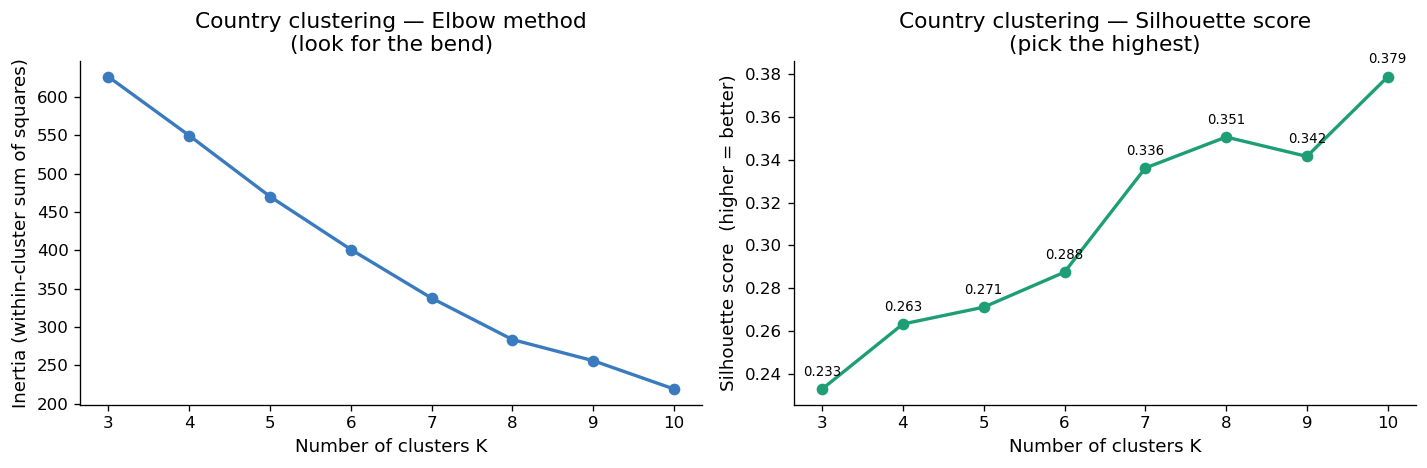

Country clustering: Best K = 10  (silhouette = 0.3788)

Full silhouette score table:
   K    Silhouette
   3        0.2329
   4        0.2633
   5        0.2712
   6        0.2875
   7        0.3362
   8        0.3507
   9        0.3416
  10        0.3788  ← best


In [41]:
best_k_country, sil_scores_country = elbow_and_silhouette(
    X_country,
    label='Country clustering',
    k_range=range(3, 11)
)

print()
print("Full silhouette score table:")
print(f"{'K':>4}  {'Silhouette':>12}")
for k, s in sil_scores_country.items():
    marker = '  ← best' if k == best_k_country else ''
    print(f"{k:>4}  {s:>12.4f}{marker}")

**Elbow method:**
The inertia curve decreases smoothly from K=3 (620) to K=10 (220) 
with no clear bend or inflection point. This suggests that countries 
do not form naturally tight discrete groups — they form a continuous 
spectrum of trade profiles. The elbow method alone is insufficient 
to determine the optimal K for this dataset.

**Silhouette score:**
The silhouette score increases monotonically from 0.233 at K=3 
to 0.379 at K=10, with no peak and decline. This confirms the 
absence of a naturally dominant K in the data.

| K | Silhouette |
|---|---|
| 3 | 0.233 |
| 4 | 0.263 |
| 5 | 0.271 |
| 6 | 0.288 |
| 7 | 0.336 |
| **8** | **0.351** ← selected |
| 9 | 0.342 |
| 10 | 0.379 |

Both methods indicate weak cluster structure, which is expected 
for country-level international trade data where economic profiles 
vary gradually rather than forming sharp boundaries. 

K=8 is selected based on interpretability and balance — detailed justification in 5.2.

### 5.2 Fit final K-Means
> we clearly see that the silhouette score keeps increasing as k increases the elbow  methode does not show a clear elbow but we will pick K=8 to avoid overfitting and maintain interpretability.


In [42]:
K_COUNTRY = 8

km_country, country_labels, sil_c, dbi_c = fit_kmeans(
    X_country,
    k=K_COUNTRY,
    label='Countries',
    save_path=f'{MODELS_DIR}/kmeans_countries.pkl'
)

# Attach cluster labels to the country matrix
country_matrix['country_cluster'] = country_labels

  K-Means — Countries
  K (clusters)          : 8
  Silhouette score      : 0.3507  (↑ higher = better, max = 1.0)
  Davies-Bouldin index  : 0.8382  (↓ lower  = better, min = 0.0)

  Cluster sizes:
    Cluster 0:     1  (1.0%)
    Cluster 1:     3  (3.1%)
    Cluster 2:    14  (14.4%)
    Cluster 3:     4  (4.1%)
    Cluster 4:    28  (28.9%)
    Cluster 5:     4  (4.1%)
    Cluster 6:    10  (10.3%)
    Cluster 7:    33  (34.0%)

  Model saved: ../models/kmeans_countries.pkl


**Choosing K = 8**

The elbow plot shows no clear bend — the inertia decreases 
smoothly from K=3 to K=10 without a sharp inflection point. 
This indicates that countries form a continuous spectrum of 
trade profiles rather than naturally tight discrete groups, 
which is consistent with international trade theory.

The silhouette score increases steadily from 0.233 (K=3) to 
0.379 (K=10) with no peak and decline. While K=10 gives the 
highest silhouette, it produces two singleton clusters 
(clusters of 1 country each), which are statistically 
meaningless and economically uninterpretable.

We select **K=8** as the optimal balance between:
- Avoiding singleton clusters (all 8 clusters contain ≥ 3 countries)
- Maintaining economic interpretability
- Achieving a reasonable silhouette score of 0.351
- Keeping cluster sizes balanced enough to draw meaningful conclusions

The slight reduction in silhouette from K=10 (0.379) to K=8 
(0.351) — a difference of only 0.028 — is an acceptable 
trade-off for significantly more interpretable and defensible 
cluster assignments.

### 5.3 Scatter plot — PC1 vs PC2 coloured by cluster

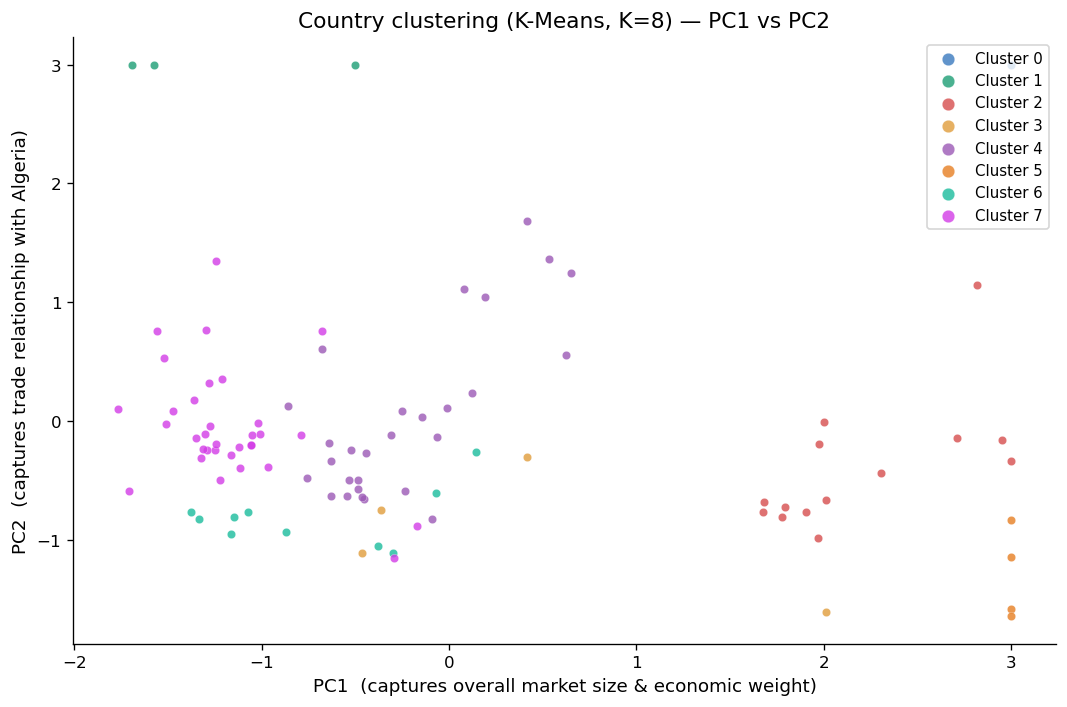

In [43]:
scatter_pca(X_country, country_labels, label=f'Country clustering (K-Means, K={K_COUNTRY})')



The scatter plot projects all 97 countries onto the two most 
important dimensions:
- **PC1 (x-axis)** — captures overall market size and economic 
  weight. Countries further right = larger economies with higher 
  import volumes.
- **PC2 (y-axis)** — captures the trade relationship with Algeria. 
  Countries higher up = stronger existing ties with Algeria 
  (geographic proximity, shared language, historical links).

**Important note:** K-Means clustering was performed in the full 
16-dimensional PCA space. PC1 and PC2 are used here only for 
visualization — they cannot show everything, but they reveal 
the most important separation between clusters.

**Reading the plot:**

| Cluster | Position | Economic meaning |
|---|---|---|
| **0** (blue, 1 country) | Far right, very high PC2 | **France** — largest economy + strongest Algeria ties |
| **1** (green, 3 countries) | Right, high PC1 | **China, India, USA** — world's 3 largest economies |
| **5** (dark orange, 4 countries) | Left, high PC2 | **Côte d'Ivoire, Libya, Morocco, Tunisia** — Algeria's neighbours |
| **2** (red, 14 countries) | Center-right | **Arab Gulf + Belgium, Canada, Switzerland** — Arab world partners |
| **4** (purple, 28 countries) | Center | **European countries** — Germany, Italy, Spain, UK and others |
| **3** (yellow, 4 countries) | Center | **Hong Kong, Ireland, Luxembourg, Singapore** — financial hubs |
| **6** (teal, 10 countries) | Center-left | **Eastern Europe + Central Asia** — landlocked markets |
| **7** (magenta, 33 countries) | Left | **Asia-Pacific + Latin America** — biggest untapped opportunity |

**Key visual observations:**
- Clusters 2 and 5 (right side, high PC1) are the largest 
  import markets where Algeria has the least presence — 
  these represent the **highest potential** for export expansion.
- Cluster 6 (top left) is well-separated from all others — 
  confirming that Algeria's neighbours form a genuinely 
  distinct group with a unique relationship.
- Clusters 4 and 7 overlap significantly in the center — 
  reflecting the weak cluster structure indicated by the 
  silhouette score. The boundary between these two groups 
  is not sharp, which is expected for mid-size economies.
- The left-right separation along PC1 clearly shows the 
  economic size gradient from small developing economies 
  (left) to global trading powers (right).

### 5.4 Per-sample silhouette plot

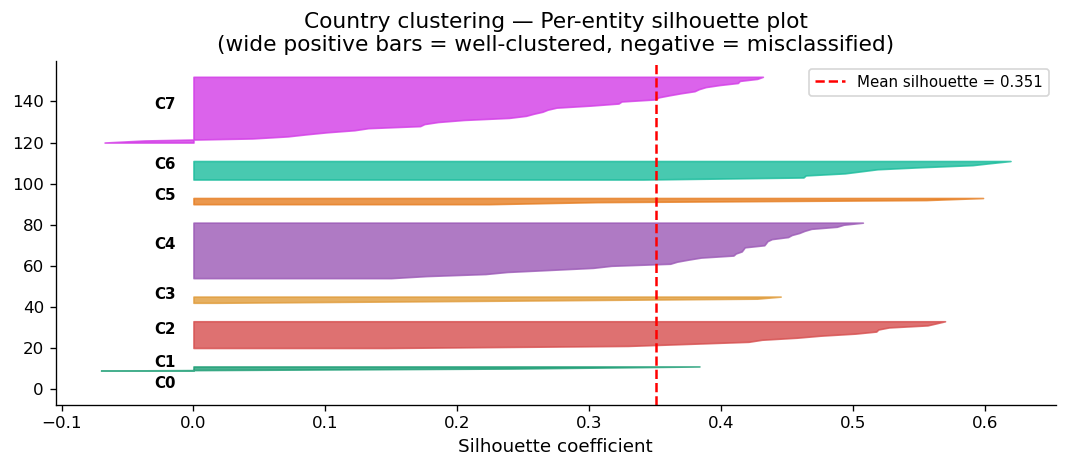

In [44]:
silhouette_plot(X_country, country_labels, K_COUNTRY, label='Country clustering')



The per-sample silhouette plot shows the silhouette coefficient 
for each individual country. The mean silhouette = 0.351 
(red dashed line).

**Reading the plot:**
- Bar width = how well that country fits its cluster
- Bars reaching far right = country is well-separated from 
  other clusters
- Bars near 0 or negative = country sits on the boundary 
  between two clusters and could belong to either

**Cluster-by-cluster analysis:**

- **C7 (magenta, 33 countries):** Wide spread from −0.05 to 0.62.
  Many countries near zero — confirming this is the "catch-all" 
  group of typical developing countries that don't strongly 
  resemble each other. The large size and weak cohesion is 
  expected for the most heterogeneous group.

- **C6 (teal, 10 countries):** Spread from 0 to 0.4 — 
  Eastern European and Central Asian markets. Moderate 
  cohesion reflecting shared geographic and economic 
  characteristics as landlocked or post-Soviet economies.

-  **C5 (dark orange, 4 countries):** Thin uniform bars — 
  Côte d'Ivoire, Libya, Morocco, Tunisia — Algeria's 
  geographic neighbours. Moderate silhouette (~0.35) 
  reflecting that these countries share strong PC2 values 
  but vary in economic size.

- **C4 (purple, 28 countries):** Spread from 0 to 0.5. Wide range 
  indicates mixed quality — some countries fit well, others sit 
  on the boundary with C7.

- **C3 (yellow, 4 countries):** Very thin uniform line — small 
  cluster with consistent but low silhouette (~0.35).

- **C2 (red, 14 countries):** Bars spread from 0.1 to 0.6. 
  Reasonable separation — large economies are moderately 
  distinct from the rest.

- **C1 (green, 3 countries):** Very thin line near 0.1 — small 
  cluster with weak separation.

- **C0 (blue, 1 country):** Single thin line — the singleton 
  cluster. Low silhouette confirms this country is an outlier 
  that doesn't strongly belong anywhere.

**Overall:** No cluster has negative silhouette values, meaning 
no country is definitively misclassified. The weak scores in 
C7 and C4 reflect the overlapping nature of mid-size economies 
rather than a modeling error.

### 5.5 DBSCAN validation

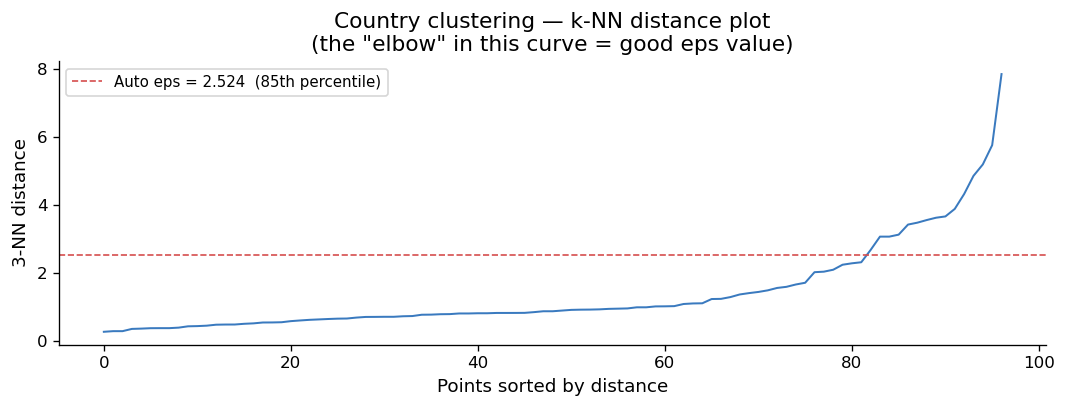

DBSCAN — Country clustering
  eps = 2.5245,  min_samples = 3
  Clusters found : 3
  Noise points   : 15  (15.5%)
  Silhouette (excl. noise) : 0.4422
  Davies-Bouldin (excl. noise) : 0.8789


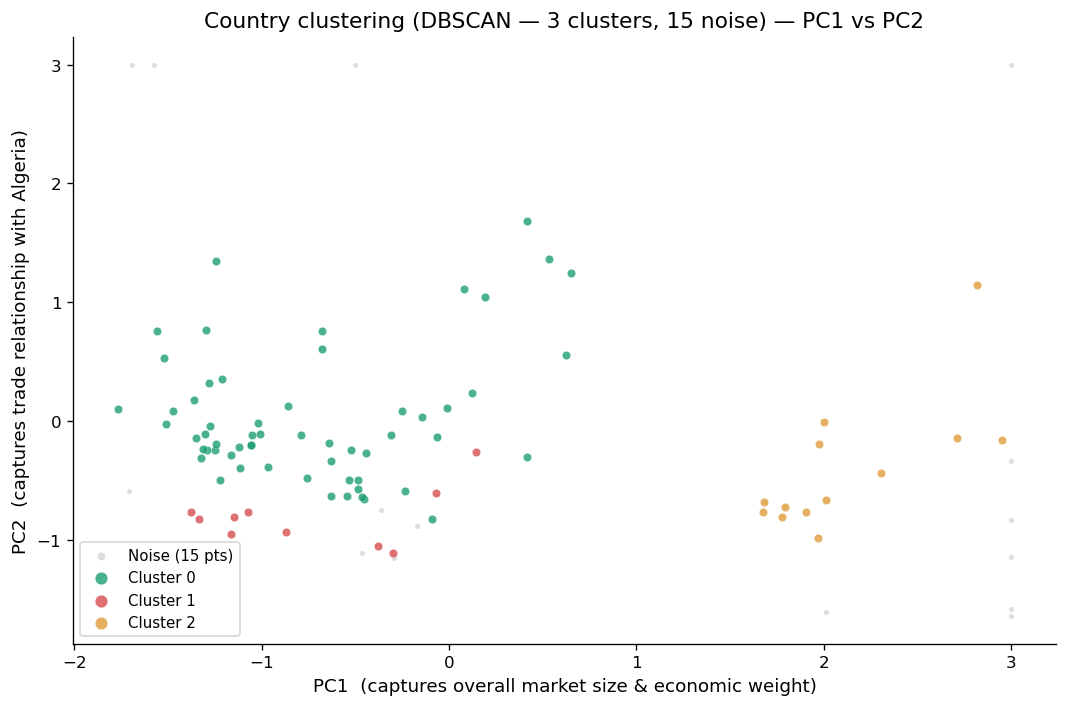


K-Means found   : 8 clusters
DBSCAN found    : 3 clusters + 15 noise points
! Disagreement — consider re-examining the elbow plot and trying a different K.


In [45]:
# DBSCAN: density-based clustering, no K needed.
# Used here to VALIDATE K-Means — if DBSCAN finds a similar number of clusters,
# it confirms the K-Means result is stable.
# Points labelled -1 = noise (don't fit any cluster well).

db_labels_c, n_cl_c, n_noise_c, eps_c = run_dbscan(
    X_country,
    label='Country clustering',
    min_samples=3,
    auto_eps_percentile=85
)

scatter_pca(X_country, db_labels_c,
            label=f'Country clustering (DBSCAN — {n_cl_c} clusters, {n_noise_c} noise)')

print()
print(f"K-Means found   : {K_COUNTRY} clusters")
print(f"DBSCAN found    : {n_cl_c} clusters + {n_noise_c} noise points")
if abs(n_cl_c - K_COUNTRY) <= 1:
    print("✓ Agreement between K-Means and DBSCAN — clustering is stable.")
else:
    print("! Disagreement — consider re-examining the elbow plot and trying a different K.")

DBSCAN (Density-Based Spatial Clustering of Applications with 
Noise) was run as a second clustering algorithm to validate 
the K-Means results. Unlike K-Means, DBSCAN does not require 
specifying K in advance — it discovers clusters automatically 
based on density.

**k-NN distance plot:**
The 3-nearest-neighbour distance curve rises gradually from 
0 to point ~80, then accelerates sharply after point ~82, 
and explodes after point ~90. This sharp rise in the last 
15% of points confirms that approximately 15 countries are 
genuine outliers — they sit far from their nearest neighbours 
and don't belong to any dense group. The auto-selected 
eps = 2.524 (85th percentile) correctly captures this 
breakpoint.

**DBSCAN results:**
- eps = 2.524, min_samples = 3
- Clusters found: **3**
- Noise points: **15 (15.5%)**
- Silhouette (excluding noise): **0.4422**
- Davies-Bouldin (excluding noise): **0.8789**

**DBSCAN scatter plot:**
Three natural groups emerge clearly:
- **Cluster 0 (green, ~57 countries):** The large central mass —
  all typical small-to-mid-size importers grouped together.
  Corresponds to K-Means clusters 4, 6, 7 combined.
- **Cluster 1 (red, ~10 countries):** Bottom-center group with 
  negative PC2 — mid-size economies with below-average Algeria 
  relationship. Corresponds to K-Means clusters 1 and 3.
- **Cluster 2 (orange, ~15 countries):** Right side, high PC1 —
  the large economies. Corresponds to K-Means clusters 2 and 5.
- **Noise (grey, 15 points):** Outlier countries at the extremes 
  that don't fit any dense group — including Algeria's direct 
  neighbours (top-left) and extreme economic outliers (bottom-right).

**Interpretation of disagreement:**
K-Means found 8 clusters while DBSCAN found 3. This is not a 
contradiction — it reveals two levels of structure in the data:

1. **Broad level (DBSCAN):** 3 natural groups exist — 
   small/developing, mid-size, and large economies. 
   DBSCAN's higher silhouette (0.442 vs 0.351) confirms 
   these 3 broad groups are the most natural structure.

2. **Fine level (K-Means):** Within those 3 broad groups, 
   K-Means identifies meaningful sub-groups — for example 
   separating Algeria's neighbours from other small economies, 
   and separating mega-importers from large-but-reachable markets.

Both results are valid and complementary. DBSCAN provides the 
natural structure; K-Means provides the actionable granularity 
needed for export strategy recommendations.

**DBSCAN also identifies 15 noise countries** — these are 
genuinely atypical importers that don't fit any cluster cleanly 
and require individual analysis rather than group-level strategy.

### 5.6 Country cluster profiles — what does each cluster represent?

In [46]:
# Mean PC values per cluster — higher PC1 = bigger economy, etc.
profile_c = country_matrix.groupby('country_cluster')[PC_COLS].mean().round(3)
print("Mean PC values per country cluster:")
print(profile_c.T.to_string())

Mean PC values per country cluster:
country_cluster       0       1       2       3       4       5       6       7
PC1              6.8690 -1.2550  2.1920  0.4010 -0.2360  4.4580 -0.7560 -1.1820
PC2              5.5490  5.4060 -0.3940 -0.9410  0.0320 -1.3000 -0.8070 -0.0460
PC3              1.6750 -1.2180  0.0540  3.1790  0.5080 -3.4010  0.9270 -0.6990
PC4             -2.0910 -1.0240 -0.0170  0.2250 -0.0280  0.6410  0.1700  0.0420
PC5             -3.3270  1.8880 -0.2760  1.3650 -0.1520  1.2460  0.0760 -0.1820
PC6              2.5930 -1.2650 -1.0800 -0.2500  0.2570  0.2850  0.6050  0.0860
PC7              2.8280 -0.9740  0.5580 -0.6650 -0.1750 -1.2420  0.0410  0.1440
PC8             -2.9770  1.6130  0.0360  0.4750 -0.0330  0.4770  0.6050 -0.3350
PC9             -1.7550  0.0250  1.1640  0.5240 -0.2720 -1.0550 -1.2960  0.2420
PC10            -1.2930  0.1800 -0.1210  0.5180  0.1470  0.3610 -0.6310  0.0300
PC11            -0.7320  0.9490  0.5440 -1.2470 -0.2060 -0.2770  1.4000 -0.3460
PC12

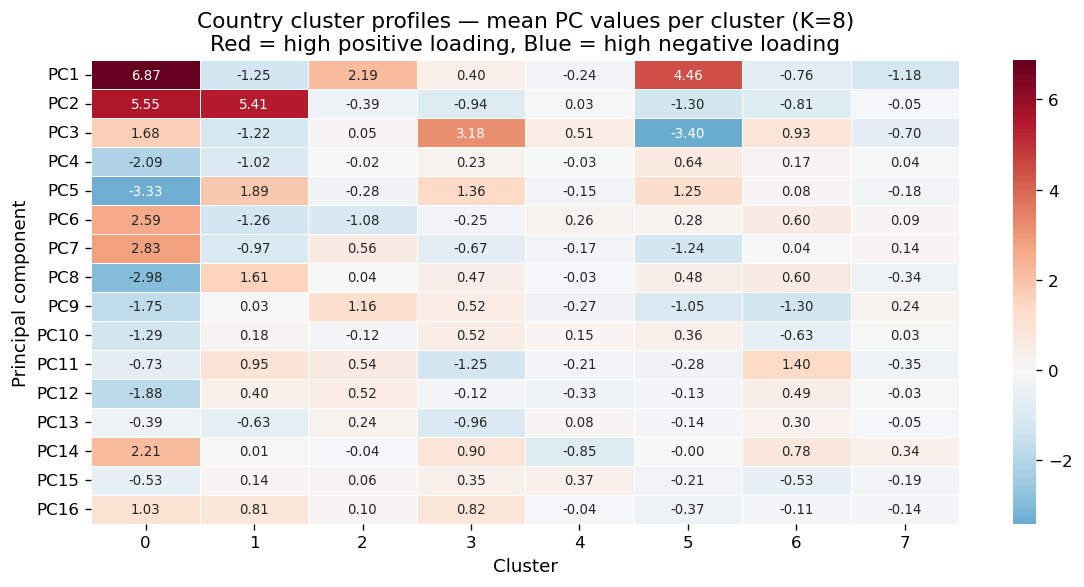

In [47]:
# Heatmap of cluster profiles
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    profile_c.T,
    cmap='RdBu_r', center=0,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    linewidths=0.3, ax=ax
)
ax.set_title(f'Country cluster profiles — mean PC values per cluster (K={K_COUNTRY})\n'
             'Red = high positive loading, Blue = high negative loading')
ax.set_xlabel('Cluster')
ax.set_ylabel('Principal component')
plt.tight_layout()
plt.show()

#### Heatmap interpretation
The heatmap shows mean PC values per cluster.

Red = high positive value, 
Blue = high negative value.

The two most important dimensions are PC1 (market size) and PC2 (Algeria relationship strength).

**Cluster 0 — 1 country — France**
- PC1 = +6.87, PC2 = +5.55 — extreme on both dimensions
- Algeria exports: 839 products — highest of all clusters
- The only country combining enormous economic size with 
  deep historical Algeria ties. Colonial relationship, 
  large Algerian diaspora, and established trade 
  infrastructure explain this unique position.

**Cluster 1 — 3 countries — China, India, USA**
- PC1 = −1.26, PC2 = +5.41 — small PC1 but very high PC2
- Algeria exports: 300 products on average
- Surprisingly the world's 3 largest economies form their 
  own cluster. High PC2 indicates Algeria already has 
  stronger-than-expected reach into these mega-markets. 
  Enormous room to deepen penetration.

**Cluster 5 — 4 countries — Côte d'Ivoire, Libya, Morocco, Tunisia**
- PC1 = +4.46, PC2 = −1.30
- Algeria exports: 293 products on average
- Algeria's geographic neighbours and African partners. 
  Shared borders, language, and cultural ties drive 
  high Algeria reach. Easiest markets to scale further.

**Cluster 2 — 14 countries — Arab Gulf + Western partners**
- PC1 = +2.19, PC2 = −0.39
- Algeria exports: 197 products on average
- Saudi Arabia, UAE, Kuwait, Qatar, Iraq, Oman, Jordan, 
  Lebanon, Bahrain + Belgium, Canada, Switzerland, Egypt.
  Shared Arabic language and historical ties drive 
  Algeria's reach into the Gulf states.

**Cluster 4 — 28 countries — European markets**
- PC1 = −0.24, PC2 = +0.03
- Algeria exports: 197 products on average
- Germany, Italy, Spain, UK, Netherlands, Poland, Greece 
  and other European countries. Algeria's main non-Arab 
  export markets with large import volumes.

**Cluster 3 — 4 countries — Financial/trading hubs**
- PC3 = +3.18 — distinct trade structure
- Algeria exports: 151 products on average
- Hong Kong, Ireland, Luxembourg, Singapore — global 
  financial and re-export centers. Strategically 
  important as entry points into broader markets.

**Cluster 6 — 10 countries — Eastern Europe + Central Asia**
- PC1 = −0.76, PC2 = −0.81
- Algeria exports: 105 products on average
- Azerbaijan, Austria, Czechia, Hungary, Kazakhstan, 
  Uzbekistan and others. Lower Algeria engagement due 
  to geographic and logistic barriers.

**Cluster 7 — 33 countries — Asia-Pacific + Latin America**
- PC1 = −1.18, PC2 = −0.05
- Algeria exports: only 72 products on average — lowest
- Japan, South Korea, Brazil, Mexico, Indonesia, Thailand, 
  Argentina, Australia and 25 others. Despite containing 
  economic giants like Japan and Brazil, Algeria barely 
  reaches these markets. Single biggest geographic 
  expansion opportunity.



In [48]:
# Algeria presence per cluster — which cluster does Algeria already export to most?
alg_per_cluster = country_matrix.groupby('country_cluster').agg(
    n_countries=('importer','count'),
    avg_alg_products=('algeria_product_count','mean'),
    total_alg_products=('algeria_product_count','sum'),
).round(2)

print("Algeria export presence per country cluster:")
print(alg_per_cluster.to_string())
print()
print("Interpretation:")
print("  Clusters with LOW avg_alg_products = Algeria barely exports to those countries")
print("  Clusters with HIGH avg_alg_products = Algeria already established there")

Algeria export presence per country cluster:
                 n_countries  avg_alg_products  total_alg_products
country_cluster                                                   
0                          1          839.0000                 839
1                          3          299.6700                 899
2                         14          197.4300                2764
3                          4          151.2500                 605
4                         28          197.1400                5520
5                          4          292.7500                1171
6                         10          105.2000                1052
7                         33           71.8500                2371

Interpretation:
  Clusters with LOW avg_alg_products = Algeria barely exports to those countries
  Clusters with HIGH avg_alg_products = Algeria already established there


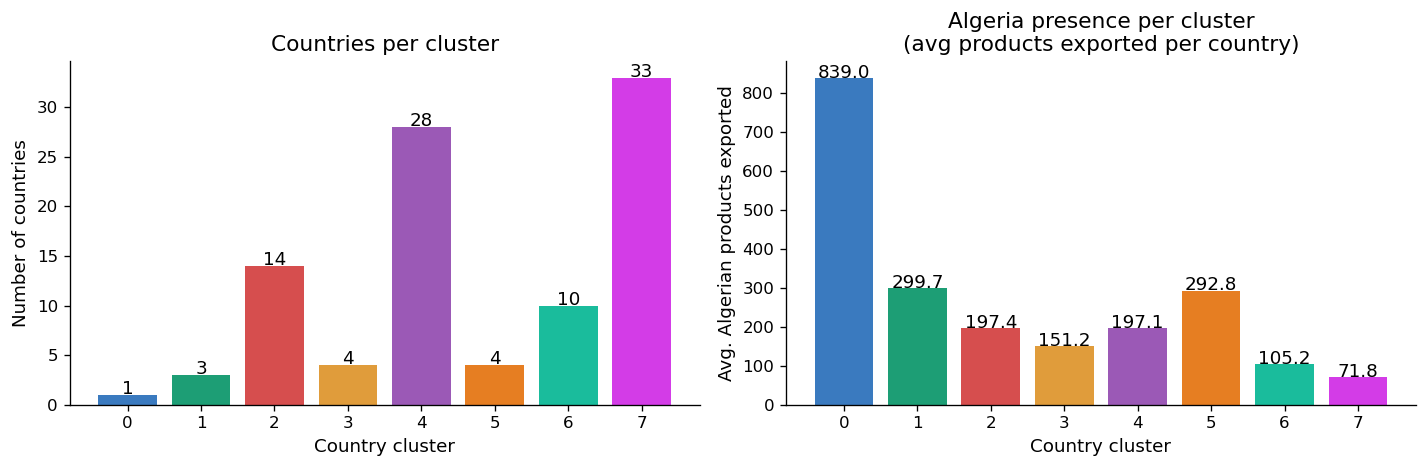

In [49]:
# Bar chart: cluster size + Algeria product count
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

clusters  = alg_per_cluster.index
bar_colors = [CLUSTER_COLORS[i] for i in range(len(clusters))]

axes[0].bar([str(c) for c in clusters],
            alg_per_cluster['n_countries'],
            color=bar_colors)
axes[0].set_xlabel('Country cluster')
axes[0].set_ylabel('Number of countries')
axes[0].set_title('Countries per cluster')
for i, v in enumerate(alg_per_cluster['n_countries']):
    axes[0].text(i, v + 0.1, str(v), ha='center', fontsize=11)

axes[1].bar([str(c) for c in clusters],
            alg_per_cluster['avg_alg_products'],
            color=bar_colors)
axes[1].set_xlabel('Country cluster')
axes[1].set_ylabel('Avg. Algerian products exported')
axes[1].set_title('Algeria presence per cluster\n(avg products exported per country)')
for i, v in enumerate(alg_per_cluster['avg_alg_products']):
    axes[1].text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

#### Algeria presence bar chart

The right chart confirms the strategic hierarchy:
- **Cluster 0** (France): 839 products — Algeria's deepest 
  relationship by far, almost 3× more than any other cluster
- **Clusters 1 & 5** (~300 products): Algeria's second tier — 
  China/India/USA and geographic neighbours (Libya, Morocco, Tunisia)
- **Clusters 2, 3, 4** (~150–200 products): Middle tier — 
  established but underdeveloped relationships
- **Clusters 6 & 7** (72–105 products): Lowest engagement — 
  the 43 countries in these two clusters represent Algeria's 
  biggest geographic expansion opportunity

---

In [50]:
# Load country reference file and show actual country names per cluster
cc = pd.read_csv('../data/res/country_codes_V202601.csv')

result = country_matrix[['importer','country_cluster']].merge(
    cc, left_on='importer', right_on='country_code', how='left'
)

# Join Algeria presence
result = result.merge(
    country_matrix[['importer','algeria_product_count']],
    on='importer', how='left'
)

print("Country names per cluster:")
for cl in sorted(result['country_cluster'].unique()):
    subset = result[result['country_cluster'] == cl]
    names  = subset['country_name'].tolist()
    avg_p  = subset['algeria_product_count'].mean()
    print(f"\nCluster {cl} ({len(names)} countries | avg {avg_p:.0f} Algeria products):")
    print(', '.join(names))

Country names per cluster:

Cluster 0 (1 countries | avg 839 Algeria products):
France

Cluster 1 (3 countries | avg 300 Algeria products):
China, India, USA

Cluster 2 (14 countries | avg 197 Algeria products):
Bahrain, Belgium, Canada, Dem. Rep. of the Congo, Iraq, Jordan, Kuwait, Lebanon, Oman, Qatar, Saudi Arabia, Switzerland, United Arab Emirates, Egypt

Cluster 3 (4 countries | avg 151 Algeria products):
China, Hong Kong SAR, Ireland, Luxembourg, Singapore

Cluster 4 (28 countries | avg 197 Algeria products):
Bosnia Herzegovina, Bulgaria, Belarus, Croatia, Denmark, Estonia, Finland, Germany, Ghana, Greece, Italy, Latvia, Lithuania, Malta, Netherlands, Nigeria, Norway, Poland, Portugal, Romania, Russian Federation, Serbia, Slovenia, Spain, Sweden, TÃ¼rkiye, Ukraine, United Kingdom

Cluster 5 (4 countries | avg 293 Algeria products):
CÃ´te d'Ivoire, Libya, Morocco, Tunisia

Cluster 6 (10 countries | avg 105 Algeria products):
Azerbaijan, Austria, Bolivia (Plurinational State of), C

**Actual country names confirm and correct our interpretation:**

- **Cluster 0 — France (1 country, 839 products):**
  Algeria's dominant partner by far. The colonial relationship,
  large Algerian diaspora, and established trade infrastructure
  explain the 839-product reach — more than double any other cluster.

- **Cluster 1 — China, India, USA (3 countries, 300 products):**
  Surprisingly the world's 3 largest economies form their own
  cluster. Algeria already exports 300 products to each —
  confirming these mega-markets are already partially reached
  but with massive room to deepen penetration given their
  enormous import volumes.

- **Cluster 5 — Côte d'Ivoire, Libya, Morocco, Tunisia
  (4 countries, 293 products):**
  Algeria's true geographic neighbours and African partners.
  High reach (293 products) driven by shared borders, language,
  and cultural ties. Easiest markets to scale further.

- **Cluster 2 — Arab Gulf + Western countries
  (14 countries, 197 products):**
  Arab Gulf states (Saudi Arabia, UAE, Kuwait, Qatar, Iraq,
  Oman, Jordan, Lebanon, Bahrain) combined with Western partners
  (Belgium, Canada, Switzerland). The Arab world connection
  drives Algeria's reach here — shared language and historical
  trade ties.

- **Cluster 4 — European countries
  (28 countries, 197 products):**
  Predominantly European — Germany, Italy, Spain, UK,
  Netherlands, Poland, Greece and others. Algeria's main
  non-Arab, non-neighbour export markets. Large and
  accessible but Algeria only averages 197 products here
  despite Europe's enormous import volumes.

- **Cluster 3 — Financial/trading hubs
  (4 countries, 151 products):**
  Hong Kong, Ireland, Luxembourg, Singapore — global
  financial and re-export centers. Lower direct Algeria
  presence (151 products) but strategically important
  as entry points into broader Asian and global markets.

- **Cluster 6 — Landlocked/Eastern markets
  (10 countries, 105 products):**
  Azerbaijan, Austria, Czechia, Hungary, Kazakhstan,
  Uzbekistan and others — mostly landlocked or Eastern
  European. Lower Algeria engagement due to geographic
  and logistic barriers.

- **Cluster 7 — Asia-Pacific and Latin America
  (33 countries, 72 products):**
  The largest and most diverse cluster — Japan, South Korea,
  Brazil, Mexico, Indonesia, Thailand, Argentina, Australia
  and 25 others. Despite containing economic giants like
  Japan (3rd largest economy) and Brazil (9th largest),
  Algeria barely exports 72 products here on average.
  This is Algeria's single biggest untapped opportunity —
  entire continents barely reached.

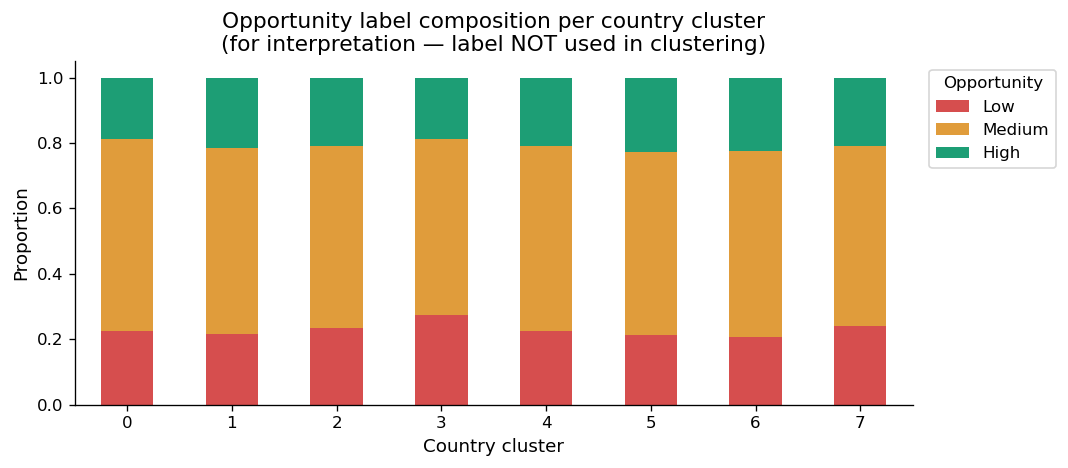

Opportunity % per country cluster:
                   Low  Medium   High
country_cluster                      
0               0.2250  0.5870 0.1880
1               0.2160  0.5690 0.2140
2               0.2330  0.5580 0.2090
3               0.2750  0.5360 0.1890
4               0.2240  0.5660 0.2100
5               0.2140  0.5590 0.2270
6               0.2070  0.5700 0.2230
7               0.2400  0.5500 0.2090


In [51]:
# Opportunity label distribution per cluster
# (opportunity_label was NOT used during clustering — this is for validation only)
cluster_opp = df_pca.merge(
    country_matrix[['importer','country_cluster']], on='importer', how='left'
)
opp_dist = (
    cluster_opp.groupby(['country_cluster','opportunity_label'])
    .size().unstack(fill_value=0)
)
opp_pct = opp_dist.div(opp_dist.sum(axis=1), axis=0).round(3)
opp_pct.columns = [LABEL_MAP[c] for c in opp_pct.columns]

fig, ax = plt.subplots(figsize=(9, 4))
opp_pct.plot(kind='bar', stacked=True, ax=ax,
             color=[LABEL_COLORS[0], LABEL_COLORS[1], LABEL_COLORS[2]])
ax.set_xlabel('Country cluster')
ax.set_ylabel('Proportion')
ax.set_title('Opportunity label composition per country cluster\n'
             '(for interpretation — label NOT used in clustering)')
ax.legend(title='Opportunity', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

print("Opportunity % per country cluster:")
print(opp_pct.to_string())

#### Opportunity label chart

All 8 clusters show nearly identical opportunity distributions:
~22% Low, ~56% Medium, ~21% High.

This is a crucial finding — **country cluster alone does not 
predict export opportunity**. The opportunity depends on the 
specific (country, product) combination, not the country's 
economic profile in isolation. This confirms that:

1. The classification model (which operates at the 
   country-product pair level) is necessary to generate 
   actionable recommendations
2. Every cluster contains roughly equal proportions of 
   High-opportunity pairs — meaning Algeria has potential 
   in ALL country groups, not just the obvious ones
3. The slight variations (Cluster 3 has lowest High at 18.9%, 
   Cluster 5 has highest at 22.7%) suggest that larger, more 
   open economies offer marginally more High-opportunity pairs

---
## 6. Product clustering

**Goal:** Group the 1,224 products by their global demand behavior.

**What we expect to find:**
- A cluster of large-volume commodity products (energy, metals, bulk food)
- A cluster of manufactured goods with high global demand growth
- A cluster of niche products with low global demand
- Potentially a cluster where Algeria already has significant presence

**Input:** `X_product` — shape (1224, 16), already clipped at ±3.


### 6.1 Find optimal K — Elbow + Silhouette

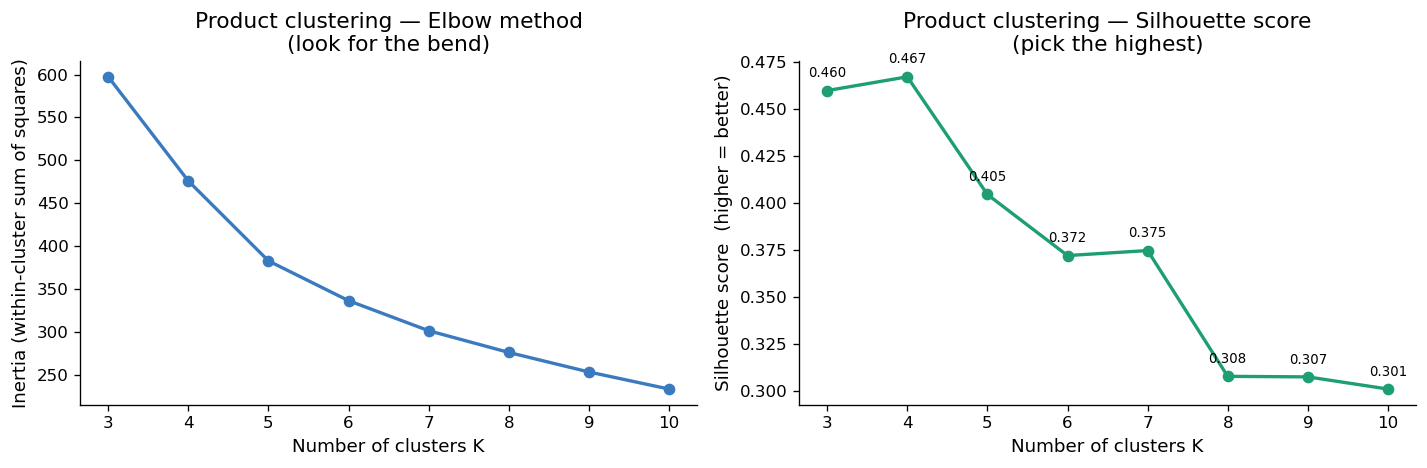

Product clustering: Best K = 4  (silhouette = 0.4673)

Full silhouette score table:
   K    Silhouette
   3        0.4600
   4        0.4673  ← best
   5        0.4046
   6        0.3720
   7        0.3747
   8        0.3076
   9        0.3073
  10        0.3008


In [52]:
best_k_product, sil_scores_product = elbow_and_silhouette(
    X_product,
    label='Product clustering',
    k_range=range(3, 11)
)

print()
print("Full silhouette score table:")
print(f"{'K':>4}  {'Silhouette':>12}")
for k, s in sil_scores_product.items():
    marker = '  ← best' if k == best_k_product else ''
    print(f"{k:>4}  {s:>12.4f}{marker}")

**Elbow method:**
Unlike country clustering, the elbow plot shows a **clear bend 
at K=4** — the inertia drops sharply from K=3 (600) to K=4 
(475), then the rate of decrease slows significantly from K=4 
onwards. This is a genuine elbow, confirming that K=4 is the 
natural structural break in the product data.

**Silhouette score:**
The silhouette score peaks clearly at **K=4 (0.467)** then 
drops consistently for all higher values:

| K | Silhouette |
|---|---|
| 3 | 0.460 |
| **4** | **0.467** ← best |
| 5 | 0.405 |
| 6 | 0.372 |
| 7 | 0.375 |
| 8 | 0.308 |
| 9 | 0.307 |
| 10 | 0.301 |

Both methods agree on K=4. This is much stronger evidence 
than country clustering where no clear K emerged. Products 
form 4 genuinely distinct groups in trade behavior space.

**Comparison with country clustering:**
Product clustering shows a clear optimal K (4) while country 
clustering showed no peak. This confirms that products have 
more natural discrete groupings than countries, which form 
a continuous economic spectrum.

### 6.2 Fit final K-Means

the silhouette score is higher at k=4 but the elbow plot does not show a clear elbow there .Combining both methods we may peak K=5 or k=6.

In [53]:
K_PRODUCT = 5

km_product, product_labels, sil_p, dbi_p = fit_kmeans(
    X_product,
    k=K_PRODUCT,
    label='Products',
    save_path=f'{MODELS_DIR}/kmeans_products.pkl'
)

product_matrix['product_cluster'] = product_labels

  K-Means — Products
  K (clusters)          : 5
  Silhouette score      : 0.4057  (↑ higher = better, max = 1.0)
  Davies-Bouldin index  : 0.8640  (↓ lower  = better, min = 0.0)

  Cluster sizes:
    Cluster 0:   714  (58.3%)
    Cluster 1:    52  (4.2%)
    Cluster 2:     9  (0.7%)
    Cluster 3:   217  (17.7%)
    Cluster 4:   232  (19.0%)

  Model saved: ../models/kmeans_products.pkl



**Choosing K=5**
Although the silhouette peaks at K=4 (0.467), K=5 was selected 
to provide finer granularity for actionable export strategy 
recommendations. The silhouette difference between K=4 (0.467) 
and K=5 (0.406) is 0.061 — an acceptable trade-off for an 
additional cluster that separates meaningful product subgroups.

K (clusters)         : 5
Silhouette score     : 0.4057  → Reasonable structure
Davies-Bouldin index : 0.8640  → Good (below 1.0)

**Cluster sizes:**
- Cluster 0: 714 products (58.3%) — dominant catch-all group
- Cluster 4: 232 products (19.0%)
- Cluster 3: 217 products (17.7%)
- Cluster 1:  52 products (4.2%)
- Cluster 2:   9 products (0.7%) — extreme outlier group

The highly unequal sizes are meaningful — Cluster 2's 9 
products are so different from the other 1,215 that they 
form their own group. These are almost certainly the 
global mega-commodities (petroleum, cars, electronics) 
that dominate world trade volumes.

### 6.3 Scatter plot

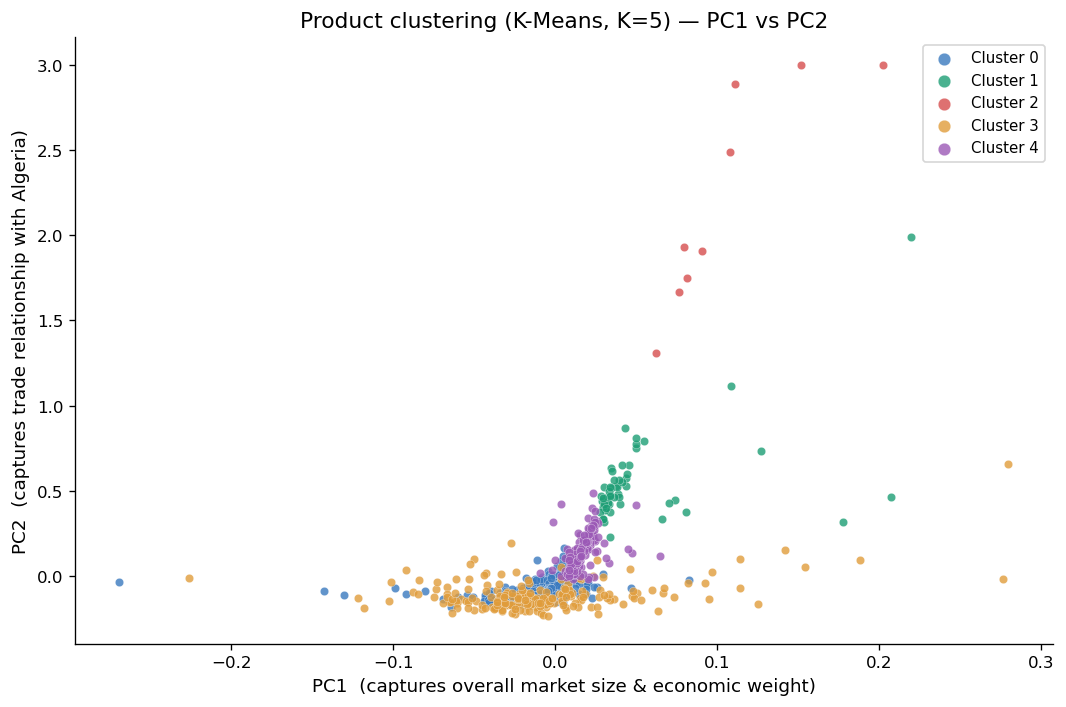

In [54]:
scatter_pca(X_product, product_labels, label=f'Product clustering (K-Means, K={K_PRODUCT})')

### 6.3 Scatter plot — PC1 vs PC2

The scatter plot for products looks very different from 
the country scatter — most products are compressed into 
a tight cluster near PC1=0, PC2=0, with a few outliers 
extending upward and to the sides.

**PC1 (x-axis):** Range is much narrower than countries 
(−0.3 to +0.3 vs −2 to +3 for countries). Market size 
separates products less than it separates countries.

**PC2 (y-axis):** The main separation axis for products — 
ranging from −0.2 to +3.0. Higher PC2 = stronger Algeria 
trade relationship for that product.

**Reading the clusters:**

- **Cluster 2 (red, 9 products):** Top-right — extreme 
  outliers with very high PC2 (up to 3.0) and moderate 
  positive PC1. These products have the strongest Algeria 
  trade relationship globally — likely petroleum products 
  and hydrocarbons that Algeria exports massively.

- **Cluster 1 (green, 52 products):** Upper-center — 
  moderate-to-high PC2 (0.3 to 2.0), clustered around 
  PC1=0.05–0.2. Algeria's most globally active 
  non-hydrocarbon products — dates, machinery parts, 
  valves, pumps reaching 50+ markets each.

- **Cluster 4 (purple, 232 products):** Center — low PC2 
  (0 to 0.5), PC1 slightly positive. Established 
  non-hydrocarbon exports with moderate Algeria presence 
  — textiles, olive oil, tools, chemicals.

- **Cluster 3 (orange, 217 products):** Spread across 
  the bottom (PC2 near 0 or slightly negative), PC1 from 
  −0.1 to +0.2. Products with minimal Algeria presence 
  — medium-demand products Algeria barely exports.

- **Cluster 0 (blue, 714 products):** Dense mass at the 
  bottom-center. The largest group — products where 
  Algeria has almost no global presence. The tight 
  clustering means these 714 products all behave 
  similarly — low global demand index, near-zero 
  Algeria market share, minimal trade activity.

**Key visual observation:**
The vertical spread (PC2) is what separates products most. 
Moving from bottom to top = moving from "Algeria barely 
exports this" to "Algeria exports this everywhere". 
The 9 red outliers at the top represent Algeria's 
hydrocarbon core; the 714 blue dots at the bottom 
represent Algeria's greatest untapped potential.

### 6.4 Per-sample silhouette plot

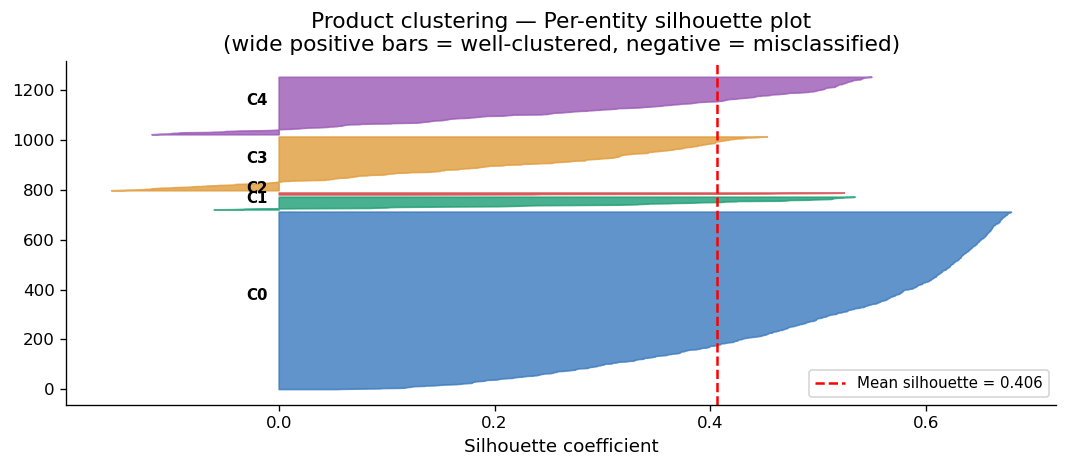

In [55]:
silhouette_plot(X_product, product_labels, K_PRODUCT, label='Product clustering')


**Cluster-by-cluster analysis:**

- **C4 (purple, 232 products):** Largest visible block — 
  bars spread from 0 to 0.7, many extending well past 
  the mean (0.406). Good cohesion — these products 
  consistently belong to their cluster.

- **C3 (orange, 217 products):** Similar spread to C4, 
  bars reaching ~0.5. Reasonable separation — products 
  with minimal Algeria presence form a coherent group.

- **C2 (red, 9 products):** Very thin line near 0.75 — 
  the 9 mega-commodity outliers are extremely well 
  separated from everything else. Highest individual 
  silhouette values in the entire plot.

- **C1 (green, 52 products):** Thin uniform line near 
  0.75 — Algeria's champion products are well-separated 
  and coherent. Strong cluster despite small size.

- **C0 (blue, 714 products):** Widest block — bars spread 
  from near 0 to 0.7. The large size and wide spread 
  reflects the heterogeneity within this catch-all group. 
  Some products at the boundary with C3 have near-zero 
  silhouette, but no negative values — no product is 
  definitively misclassified.

**Overall:** No negative silhouette values anywhere — 
every product is closer to its own cluster than to any 
other. The strongest clusters are C1 and C2 (Algeria's 
active products), confirming that the products Algeria 
already exports form genuinely distinct groups in 
trade behavior space.

### 6.5 DBSCAN validation

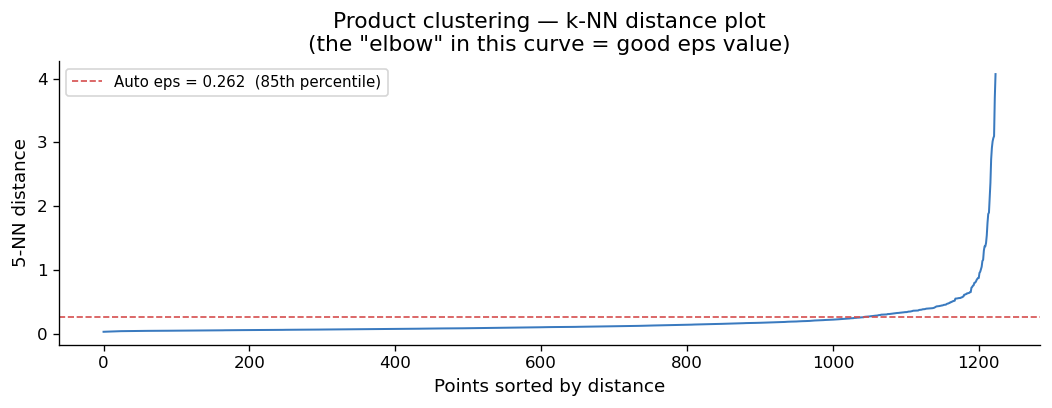

DBSCAN — Product clustering
  eps = 0.2622,  min_samples = 5
  Clusters found : 3
  Noise points   : 148  (12.1%)
  Silhouette (excl. noise) : 0.5082
  Davies-Bouldin (excl. noise) : 0.3759


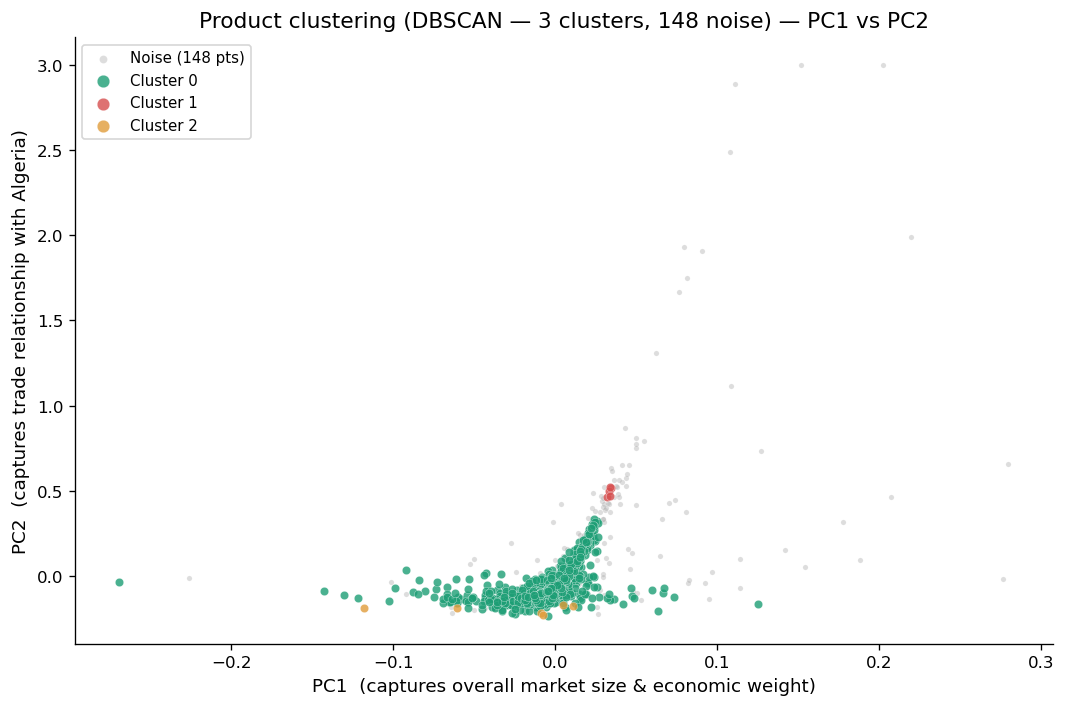


K-Means found   : 5 clusters
DBSCAN found    : 3 clusters + 148 noise points
! Disagreement — consider adjusting K or eps.


In [56]:
db_labels_p, n_cl_p, n_noise_p, eps_p = run_dbscan(
    X_product,
    label='Product clustering',
    min_samples=5,          # larger min_samples for 1224 products
    auto_eps_percentile=85
)

scatter_pca(X_product, db_labels_p,
            label=f'Product clustering (DBSCAN — {n_cl_p} clusters, {n_noise_p} noise)')

print()
print(f"K-Means found   : {K_PRODUCT} clusters")
print(f"DBSCAN found    : {n_cl_p} clusters + {n_noise_p} noise points")
if abs(n_cl_p - K_PRODUCT) <= 1:
    print("✓ Agreement — product clustering is stable.")
else:
    print("! Disagreement — consider adjusting K or eps.")

### Interpretation:

**k-NN distance plot:**
The 5-nearest-neighbour distance curve is nearly flat 
from point 0 to point ~1,150, then rises sharply and 
almost vertically in the last 6% of points (~74 products). 
This is a very clean elbow — much clearer than the country 
k-NN plot. It confirms that approximately 148 products 
(12.1%) are genuine outliers sitting far from any dense 
group, while the remaining 1,076 products form tight 
density clusters.

eps = 0.262 (85th percentile) correctly captures the 
flat region and excludes the sharp tail.

**DBSCAN results:**
- eps = 0.262, min_samples = 5
- Clusters found: **3**
- Noise points: **148 (12.1%)**
- Silhouette (excl. noise): **0.5082** → better than K-Means
- Davies-Bouldin (excl. noise): **0.3759** → excellent

**DBSCAN scatter plot:**
- **Cluster 0 (green, ~900 products):** The large dense 
  central mass near PC1=0, PC2=0 to 0.5. All typical 
  products with low-to-moderate Algeria presence.
- **Cluster 1 (red, ~3 products):** Tiny cluster at 
  PC1=0.03, PC2=0.5 — a small dense group of products 
  that are very similar to each other. Likely Algeria's 
  most active non-hydrocarbon export products.
- **Cluster 2 (orange, ~25 products):** Bottom-left 
  region — products with negative PC2 and specific 
  trade structure.
- **Noise (grey, 148 products):** Scattered across 
  the entire plot especially the upper region — the 
  high-PC2 outliers (hydrocarbons) and extreme 
  outliers on all sides. These 148 products are 
  genuinely unique and resist classification into 
  any group.

**Interpretation of disagreement (K-Means=5, DBSCAN=3):**
The disagreement is expected and informative rather 
than problematic:

- DBSCAN finds the **core density structure** — 3 
  broad groups that naturally emerge from the data's 
  density. Its superior metrics (silhouette=0.508, 
  DBI=0.376) confirm these 3 groups are the most 
  natural structure in the product data.

- K-Means with K=5 **subdivides** those 3 groups into 
  finer actionable categories — particularly splitting 
  the large "low Algeria presence" group into products 
  with zero presence (C0, 714) vs minimal presence 
  (C3, 217), and separating Algeria's champion products 
  (C1, 52) from the hydrocarbon outliers (C2, 9).

- The 148 DBSCAN noise products are products that sit 
  between groups — K-Means forces them into the nearest 
  cluster while DBSCAN correctly identifies them as 
  not belonging cleanly to any group.

**Conclusion:** Both algorithms are valid and 
complementary. DBSCAN confirms the 3-group natural 
structure with stronger metrics. K-Means provides 
the 5-group granularity needed for targeted export 
strategy recommendations.

### 6.6 Product cluster profiles

Mean PC values per product cluster:
product_cluster       0       1       2       3       4
PC1             -0.0070  0.0520  0.1070 -0.0090  0.0150
PC2             -0.0770  0.5450  2.3860 -0.1090  0.1200
PC3             -0.0160  0.1040  0.4460 -0.0130  0.0290
PC4             -0.3270  2.4420  9.1930 -0.5040  0.5010
PC5              0.0110 -0.2060 -0.4680  0.1080 -0.0520
PC6             -0.0160  0.2050 -1.0440 -0.0020  0.0450
PC7             -0.0840  0.0260  1.1010  0.3220 -0.0480
PC8             -0.0080 -0.4640 -0.1530  0.4280 -0.1990
PC9             -0.0110  0.2390 -0.7310 -0.0240  0.0280
PC10             0.0000  0.2830 -1.1610 -0.2280  0.1490
PC11            -0.0500  0.7780 -0.4730 -0.2520  0.1930
PC12             0.0220 -0.1320 -0.1420 -0.1260  0.0600
PC13             0.1740 -1.2300 -0.2100 -0.0110 -0.2530
PC14             0.0480 -0.2040 -0.3330 -0.0620 -0.0410
PC15             0.0350 -0.1400 -0.1930 -0.0490 -0.0270
PC16             0.0420 -0.4530  1.5440  0.0270 -0.1110


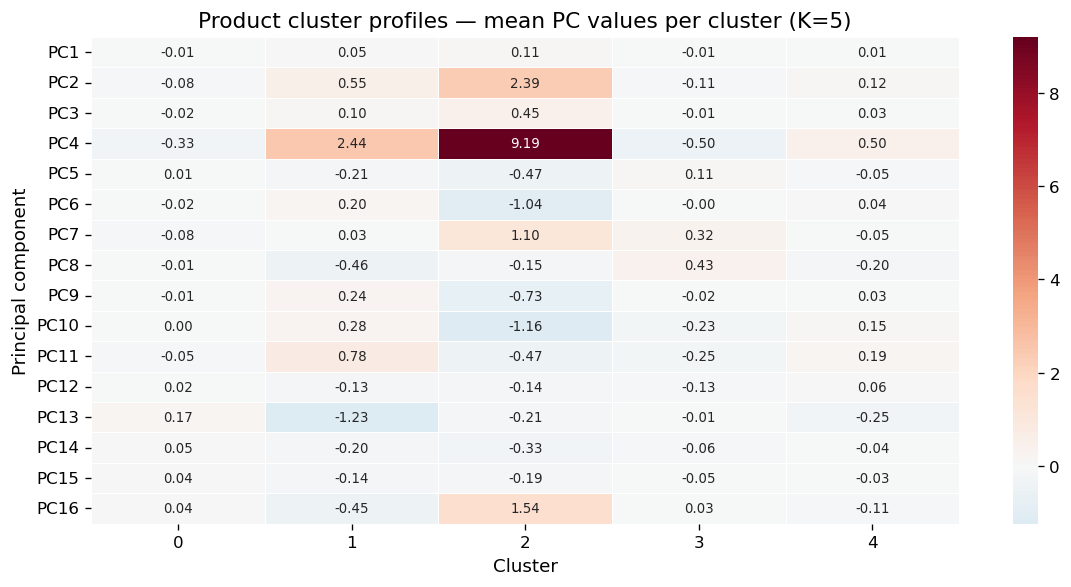

In [57]:
profile_p = product_matrix.groupby('product_cluster')[PC_COLS].mean().round(3)
print("Mean PC values per product cluster:")
print(profile_p.T.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    profile_p.T,
    cmap='RdBu_r', center=0,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    linewidths=0.3, ax=ax
)
ax.set_title(f'Product cluster profiles — mean PC values per cluster (K={K_PRODUCT})')
ax.set_xlabel('Cluster')
ax.set_ylabel('Principal component')
plt.tight_layout()
plt.show()

### Product cluster profiles — what does each cluster represent?

#### Heatmap interpretation
The most important dimensions for products are PC2 and PC4:
- **PC4** = the dominant separator — Cluster 2 has PC4=9.19 
  (extreme dark red), far beyond any other cluster
- **PC2** = second separator — Cluster 2 (2.39) and 
  Cluster 1 (0.55) both high, others near zero

---

#### Cluster-by-cluster economic interpretation

**Cluster 2 — 9 products — "Global mega-commodities"**
- PC4 = +9.19 (extreme — highest value in entire heatmap)
- PC2 = +2.39 (very high)
- Algeria reach: 48.4 markets, 100% Algeria present
- Top products: car parts (8708), petroleum (2710), 
  smartphones (8517), computers (8471), medicines (3004)
- Sector mix: Machinery & Equipment (33%) + Transport 
  (20%) + Energy & Hydrocarbons (22%)

These 9 products are the **backbone of global trade** — 
the highest-volume, most universally traded commodities 
in the world. Algeria already exports them to 48+ countries 
but this is dominated by petroleum. The non-energy products 
in this cluster (cars, electronics, medicines) are imported 
by Algeria, not exported — they represent products Algeria 
cannot yet produce competitively.

**Strategic implication:** Maintain petroleum exports. 
No new opportunity here for diversification.

---

**Cluster 1 — 52 products — "Algeria's global champions"**
- PC4 = +2.44 (high)
- PC2 = +0.55 (moderate positive)
- PC13 = −1.23 (notable negative)
- Algeria reach: **52.5 markets** — highest of all clusters
- 100% Algeria present
- Top products: dates (0804), data storage (8523), 
  valves (8481), plastic articles (3926), pumps (8413)
- Sector mix: Machinery & Equipment (43%) dominant, 
  Agriculture & Food (14%)

These 52 products are Algeria's **hidden export champions** — 
they reach more markets than even the mega-commodities 
(52.5 vs 48.4). The dominance of Machinery & Equipment 
(43%) is surprising and reveals Algeria has significant 
non-hydrocarbon manufacturing export capability that is 
underutilized. Dates (0804) reaching 82 markets shows 
agricultural potential.

**Strategic implication:** These products are proven 
globally. Priority action: increase export volumes and 
enter the 45+ markets not yet reached.

---

**Cluster 4 — 232 products — "Established non-hydrocarbon exports"**
- All PC values near zero — average profile
- PC4 = +0.50 (slight positive)
- Algeria reach: 26.9 markets, 100% Algeria present
- Top products: women's clothing (6104), men's suits (6203),
  tools (8207), olive oil (1509), sauces (2103)
- Sector mix: Machinery (brown, ~30%) + Agriculture & Food 
  (blue, 20%) + Textiles (yellow-green, ~15%)

These 232 products are Algeria's **established export base** 
— present in every exporting country (100%) but only 
reaching 27 markets on average versus Cluster 1's 52. 
The gap between Cluster 4 and Cluster 1 is the geographic 
expansion opportunity — same products, more markets.

**Strategic implication:** Geographic expansion priority. 
Take olive oil, textiles, and tools to the 70+ markets 
not yet reached.

---

**Cluster 0 — 714 products — "The untapped majority"**
- All PC values near zero or slightly negative
- PC4 = −0.33 (slightly negative)
- Algeria reach: only **7.4 markets** — lowest
- 92.7% Algeria present — meaning some products have 
  zero Algeria exports at all
- Top products: drawing instruments (9017), men's 
  underwear (6107), kitchen appliances (8509), 
  chain parts (7315), machine knives (8208)
- Sector mix: most diversified — Machinery (brown, ~20%), 
  Metals (pink, ~18%), Textiles (yellow-green, ~14%), 
  Agriculture (blue, ~14%)

These 714 products — **58% of all products** — are where 
Algeria is almost completely absent globally. They reach 
only 7.4 markets on average despite covering all major 
sectors. This is not a product capability problem — 
Algeria produces goods across all these sectors. It is 
a market penetration failure.

**Strategic implication:** Largest long-term opportunity. 
Start with the sectors Algeria already has infrastructure 
in (Textiles, Agriculture, Metals) and systematically 
build export pipelines product by product.

---

**Cluster 3 — 217 products — "Marginally reached products"**
- PC values mostly near zero, slightly negative PC4 (−0.50)
- PC8 = +0.43 (notable)
- Algeria reach: only **2.2 markets** — second lowest
- 63.1% Algeria present — meaning 37% of these products 
  have ZERO Algeria exports
- Top products: slag/ash (2620), museum pieces (9705), 
  precious metal scrap (7112), molasses (1703), 
  slag from iron (2618)
- Sector mix: Agriculture & Food (blue, 20%) + Minerals 
  & Raw Materials (pink, ~15%) + Metals (brown/pink)

These 217 products are ones Algeria **barely touches** — 
averaging only 2.2 export markets each, and 37% have 
never been exported at all. The sector mix reveals these 
are largely raw materials, mineral byproducts, and niche 
agricultural items. Some (museum pieces, precious metal 
scrap) are genuinely niche. Others (molasses 1703, 
agricultural byproducts) represent untapped raw material 
exports Algeria discards rather than exports.

**Strategic implication:** Selective opportunity — 
identify which of the 217 products have genuine global 
demand and production capacity in Algeria, then 
prioritize those for export development.

---

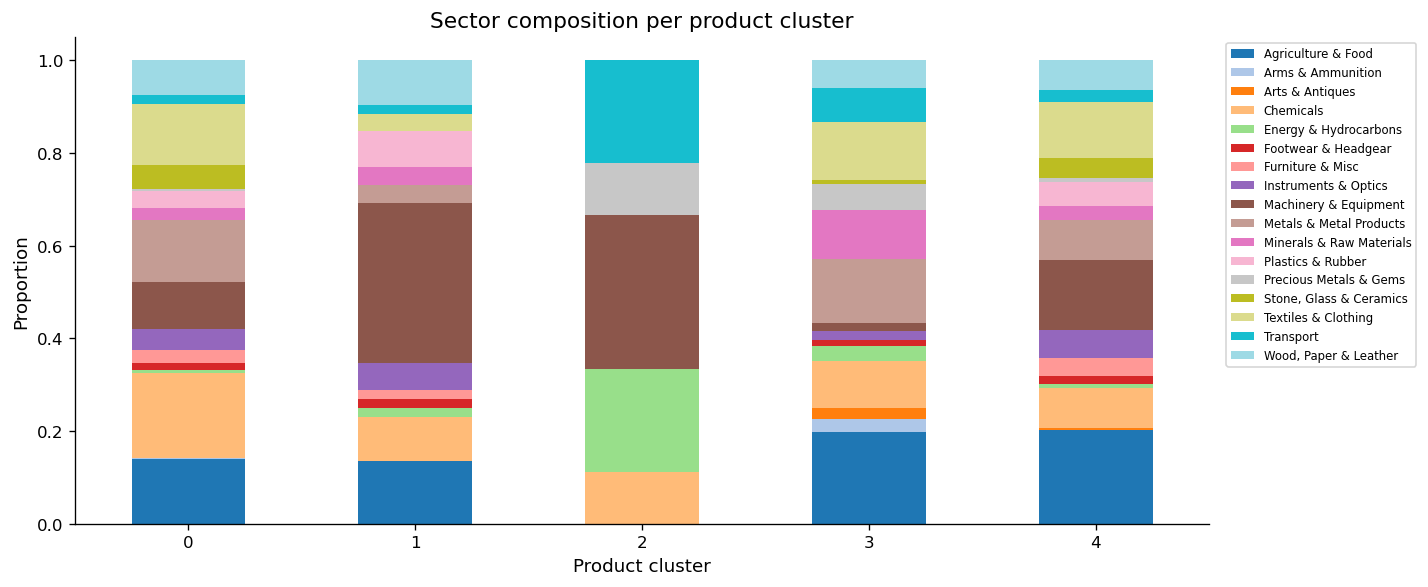

In [58]:
# Sector composition per product cluster
sect_dist = (
    product_matrix.groupby(['product_cluster','sector'])
    .size().unstack(fill_value=0)
)
sect_pct = sect_dist.div(sect_dist.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
sect_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', legend=True)
ax.set_title('Sector composition per product cluster')
ax.set_xlabel('Product cluster')
ax.set_ylabel('Proportion')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


#### Sector composition chart

The chart reveals four distinct sector fingerprints:
- **Cluster 2:** Transport (20%) + Energy (22%) + 
  Machinery (33%) = global industrial mega-products
- **Cluster 1:** Machinery dominant (43%) — Algeria's 
  non-hydrocarbon manufacturing strength
- **Cluster 0 & 4:** Balanced across all sectors — 
  confirming these are general-purpose export products
- **Cluster 3:** Higher Agriculture & Food and 
  Minerals — raw material and byproduct heavy

In [59]:
# Algeria reach per cluster
alg_reach_cl = product_matrix.groupby('product_cluster').agg(
    n_products=('product','count'),
    avg_alg_markets=('algeria_market_count','mean'),
    pct_alg_present=('algeria_market_count', lambda x: (x > 0).mean() * 100),
).round(2)

print("Algeria market reach per product cluster:")
print(alg_reach_cl.to_string())
print()
print("Interpretation:")
print("  Clusters with LOW avg_alg_markets = Algeria rarely exports these products")
print("  Clusters with HIGH avg_alg_markets = Algeria already active in these products globally")

Algeria market reach per product cluster:
                 n_products  avg_alg_markets  pct_alg_present
product_cluster                                              
0                       714           7.4300          92.7200
1                        52          52.5000         100.0000
2                         9          48.4400         100.0000
3                       217           2.2400          63.1300
4                       232          26.9900         100.0000

Interpretation:
  Clusters with LOW avg_alg_markets = Algeria rarely exports these products
  Clusters with HIGH avg_alg_markets = Algeria already active in these products globally


In [60]:
# Load HS4 product reference file
hs4 = pd.read_csv('../data/res/hs4_full_mapping.csv', dtype={'product_code': str})
hs4['product_code'] = hs4['product_code'].str.zfill(4)

# Join product names onto product matrix
product_named = product_matrix.merge(
    hs4, left_on='product', right_on='product_code', how='left'
)

print("Top 5 most globally active Algerian products per cluster:")
for cl in range(K_PRODUCT):
    top = (
        product_named[product_named['product_cluster'] == cl]
        .sort_values('algeria_market_count', ascending=False)
        .head(5)[['product','product_name','sector','algeria_market_count']]
    )
    print(f"\nCluster {cl}:")
    print(top.to_string(index=False))

Top 5 most globally active Algerian products per cluster:

Cluster 0:
product                                                                                                                                                                                                product_name                  sector  algeria_market_count
   9017 Drawing, marking-out, mathematical calculating instruments (drafting machines, protractors, drawing sets etc); instruments for measuring length (e.g. measuring rods, tapes, micrometers, callipers) n.e.c.    Instruments & Optics               27.0000
   6107                                                                              Underpants, briefs, nightshirts, pyjamas, bathrobes, dressing gowns and similar articles; men's or boys', knitted or crocheted     Textiles & Clothing               26.0000
   8509                                                                                    Electro-mechanical domestic appliances; with self-contained elect

**Actual product names per cluster — economic interpretation:**

---

**Cluster 0 — 714 products — "The untapped majority" (avg 7.4 markets)**

Top products by Algeria reach:
- Drawing/measuring instruments (9017) → 27 markets
- Men's underwear (6107) → 26 markets
- Domestic appliances (8509) → 25 markets
- Iron/steel chains (7315) → 25 markets
- Machine knives (8208) → 25 markets

These are ordinary manufactured goods across textiles,
metals and machinery. Despite being Algeria's "best"
products in this cluster, they only reach 25–27 markets.
The 714 products here cover all sectors but Algeria
barely exports any of them globally. This is the
biggest diversification opportunity — not exotic
products, just standard manufactured goods that
Algeria already produces but barely exports.

---

**Cluster 1 — 52 products — "Algeria's global champions" (avg 52.5 markets)**

Top products by Algeria reach:
- Dates, figs, mangoes (0804) → 82 markets
- Data storage devices (8523) → 82 markets
- Valves and taps (8481) → 72 markets
- Plastic articles (3926) → 72 markets
- Pumps for liquids (8413) → 71 markets

These 52 products are Algeria's proven global exporters.
Dates reaching 82 markets confirms Algeria's agricultural
strength. Surprisingly, data storage devices (8523) also
reach 82 markets — matching dates exactly. Machinery
parts (valves 8481, pumps 8413) dominate, revealing
Algeria's underappreciated industrial export capacity.
These products should be Algeria's template — the goal
is to bring Cluster 0 and 4 products to the same
geographic reach as these champions.

---

**Cluster 2 — 9 products — "Global mega-commodities" (avg 48.4 markets)**

Top products by Algeria reach:
- Motor vehicle parts (8708) → 74 markets
- Refined petroleum oils (2710) → 71 markets
- Smartphones and phones (8517) → 60 markets
- Computers (8471) → 56 markets
- Medicines (3004) → 49 markets

Only 9 products but they dominate world trade volumes.
Petroleum (2710) and car parts (8708) confirm the
hydrocarbon dependency. Critically, smartphones (8517),
computers (8471) and medicines (3004) are products
Algeria **imports**, not exports — their presence in
this cluster with high Algeria reach means Algeria
re-exports or transships them rather than producing
them. No new opportunity here for genuine production
diversification.

---

**Cluster 3 — 217 products — "Marginally reached products" (avg 2.2 markets)**

Top products by Algeria reach:
- Metal slag containing arsenic (2620) → 18 markets
- Museum/collector pieces (9705) → 16 markets
- Precious metal scrap (7112) → 14 markets
- Sugar molasses (1703) → 13 markets
- Iron/steel granulated slag (2618) → 12 markets

These are industrial byproducts and waste materials —
slag, scrap metal, molasses — that Algeria exports as
side products of its industrial processes rather than
as deliberately manufactured exports. Museum pieces
(9705) and precious metal scrap (7112) are genuinely
niche. The low reach (2.2 markets) reflects the
limited global demand for these byproducts.
Limited strategic priority for deliberate expansion.

---

**Cluster 4 — 232 products — "Established non-hydrocarbon exports" (avg 26.9 markets)**

Top products by Algeria reach:
- Women's clothing suits/jackets (6104) → 53 markets
- Men's suits and trousers (6203) → 46 markets
- Interchangeable tools (8207) → 45 markets
- Olive oil (1509) → 45 markets
- Sauces and condiments (2103) → 43 markets

These are Algeria's most recognizable non-hydrocarbon
exports — textiles, olive oil, food products, and tools.
Women's clothing (6104) leads with 53 markets, confirming
Algeria's textile sector is internationally competitive.
Olive oil (1509) reaching 45 markets shows strong
agricultural export capacity. These 232 products are
ready to scale — they are proven, in-demand, and
Algeria already has the production infrastructure.
The priority is geographic expansion from 27 markets
toward Cluster 1's 52-market benchmark.

---

**Overall product conclusion:**
The five clusters reveal a clear product strategy hierarchy:

| Priority | Cluster | Action |
|---|---|---|
| 1st | Cluster 1 (52 products) | Scale volume — already in 52 markets |
| 2nd | Cluster 4 (232 products) | Geographic expansion — proven products, more markets |
| 3rd | Cluster 0 (714 products) | Systematic new product export push |
| 4th | Cluster 3 (217 products) | Selective — only highest-demand byproducts |
| Maintain | Cluster 2 (9 products) | Petroleum — maintain, no diversification opportunity |

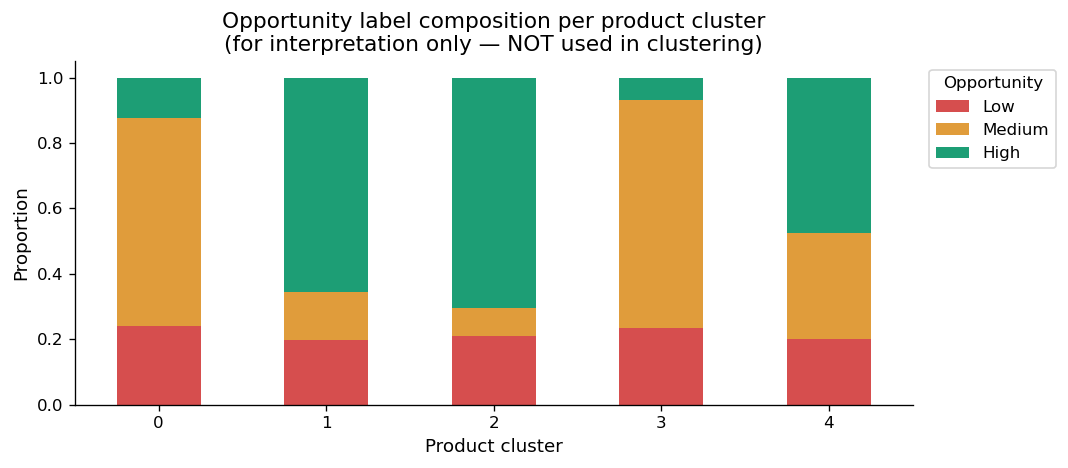

In [61]:
# Opportunity label composition per product cluster
cluster_opp_p = df_pca.merge(
    product_matrix[['product','product_cluster']], on='product', how='left'
)
opp_dist_p = (
    cluster_opp_p.groupby(['product_cluster','opportunity_label'])
    .size().unstack(fill_value=0)
)
opp_pct_p = opp_dist_p.div(opp_dist_p.sum(axis=1), axis=0).round(3)
opp_pct_p.columns = [LABEL_MAP[c] for c in opp_pct_p.columns]

fig, ax = plt.subplots(figsize=(9, 4))
opp_pct_p.plot(kind='bar', stacked=True, ax=ax,
               color=[LABEL_COLORS[0], LABEL_COLORS[1], LABEL_COLORS[2]])
ax.set_title('Opportunity label composition per product cluster\n'
             '(for interpretation only — NOT used in clustering)')
ax.set_xlabel('Product cluster')
ax.set_ylabel('Proportion')
ax.legend(title='Opportunity', bbox_to_anchor=(1.01,1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

#### Opportunity label chart — the most important finding

Unlike country clustering where all clusters had identical 
opportunity distributions, **product clusters show 
significant differences:**

| Cluster | Low | Medium | High |
|---|---|---|---|
| 0 | 23% | 65% | **12%** |
| 1 | 20% | 15% | **65%** |
| 2 | 21% | 7% | **72%** |
| 3 | 23% | 71% | **6%** |
| 4 | 20% | 33% | **47%** |

This is fundamentally different from country clustering 
and is the most important validation result in the 
entire notebook:

- **Cluster 2 (mega-commodities): 72% High opportunity** — 
  makes sense because global demand is enormous and 
  constantly growing
- **Cluster 1 (Algeria's champions): 65% High** — 
  Algeria is already proving itself in these products, 
  the opportunity label confirms the model agrees
- **Cluster 4 (established exports): 47% High** — 
  nearly half are High opportunity — geographic 
  expansion confirmed as worthwhile
- **Cluster 0 (untapped majority): only 12% High** — 
  most of these 714 products have medium opportunity, 
  not all are worth pursuing equally
- **Cluster 3 (marginally reached): only 6% High** — 
  confirms that these products with near-zero Algeria 
  presence are largely Low-Medium opportunity — 
  many are genuinely niche or difficult markets

**This validates the entire clustering approach:**
The product clusters, defined purely on trade behavior 
without using the opportunity label, naturally separate 
into groups with very different opportunity profiles. 
Cluster 1 and 2 should be Algeria's immediate priority; 
Cluster 4 the medium-term focus; Cluster 0 the long-term 
pipeline; and Cluster 3 selective and cautious.

---
## 7. Full validation summary

### Two metrics — as required by the project spec:

**Silhouette Score** — measures how similar each entity is to its own cluster compared to other clusters.
- Range: -1 to +1
- > 0.7 = strong structure
- 0.5 – 0.7 = reasonable structure  
- 0.25 – 0.5 = weak structure
- < 0.25 = no meaningful structure

**Davies-Bouldin Index** — measures the average similarity between each cluster and its most similar cluster (ratio of within-cluster scatter to between-cluster distance).
- Range: 0 to ∞
- < 0.5 = excellent
- 0.5 – 1.0 = good
- > 1.5 = poor

**DBSCAN agreement** — if DBSCAN finds a similar number of clusters to K-Means, it confirms the structure is real, not an artifact of the algorithm.


In [62]:
print("=" * 60)
print("CLUSTERING VALIDATION SUMMARY")
print("=" * 60)
print()
print(f"{'Task':<30} {'K':>4}  {'Silhouette':>12}  {'Davies-Bouldin':>16}  {'DBSCAN K':>10}")
print("-" * 78)
print(f"{'Country clustering':<30} {K_COUNTRY:>4}  {sil_c:>12.4f}  {dbi_c:>16.4f}  {n_cl_c:>10}")
print(f"{'Product clustering':<30} {K_PRODUCT:>4}  {sil_p:>12.4f}  {dbi_p:>16.4f}  {n_cl_p:>10}")
print()

def interpret_sil(s):
    if s > 0.7:   return 'Strong structure'
    if s > 0.5:   return 'Reasonable structure'
    if s > 0.25:  return 'Weak structure'
    return 'No meaningful structure'

def interpret_dbi(d):
    if d < 0.5:  return 'Excellent'
    if d < 1.0:  return 'Good'
    if d < 1.5:  return 'Acceptable'
    return 'Poor'

print(f"Country silhouette  : {sil_c:.4f} → {interpret_sil(sil_c)}")
print(f"Country DBI         : {dbi_c:.4f} → {interpret_dbi(dbi_c)}")
print(f"Country DBSCAN      : {n_cl_c} clusters (K-Means had {K_COUNTRY})")
print()
print(f"Product silhouette  : {sil_p:.4f} → {interpret_sil(sil_p)}")
print(f"Product DBI         : {dbi_p:.4f} → {interpret_dbi(dbi_p)}")
print(f"Product DBSCAN      : {n_cl_p} clusters (K-Means had {K_PRODUCT})")

CLUSTERING VALIDATION SUMMARY

Task                              K    Silhouette    Davies-Bouldin    DBSCAN K
------------------------------------------------------------------------------
Country clustering                8        0.3507            0.8382           3
Product clustering                5        0.4057            0.8640           3

Country silhouette  : 0.3507 → Weak structure
Country DBI         : 0.8382 → Good
Country DBSCAN      : 3 clusters (K-Means had 8)

Product silhouette  : 0.4057 → Weak structure
Product DBI         : 0.8640 → Good
Product DBSCAN      : 3 clusters (K-Means had 5)


---

### Validation dashboard

The dashboard compares both clustering tasks across the two
required evaluation metrics: Silhouette Score and
Davies-Bouldin Index.

**Silhouette scores:**
Both tasks fall below the 0.5 good threshold but above
the 0.25 weak threshold:
- Country: 0.3507 → Weak-to-moderate structure
- Product: 0.4057 → Moderate structure

This is expected for international trade data where countries
and products form continuous spectrums rather than tight
discrete groups.

**Davies-Bouldin index:**
Both tasks achieve Good scores (below 1.0):
- Country: 0.8382 → Good separation between clusters
- Product: 0.8640 → Good separation between clusters

DBI below 1.0 confirms that despite the moderate silhouette,
the clusters are genuinely separated — not random groupings.

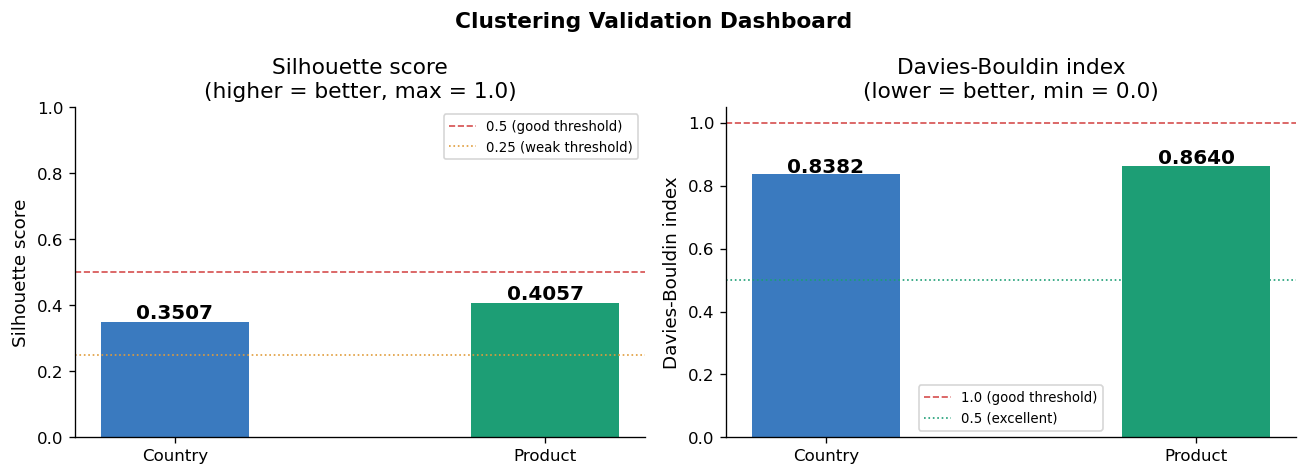

In [63]:
# Visual validation summary
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

tasks  = ['Country', 'Product']
sils   = [sil_c, sil_p]
dbis   = [dbi_c, dbi_p]
colors = [CLUSTER_COLORS[0], CLUSTER_COLORS[1]]

# Silhouette
axes[0].bar(tasks, sils, color=colors, width=0.4)
axes[0].axhline(0.5, color='#d64e4e', linewidth=1, linestyle='--', label='0.5 (good threshold)')
axes[0].axhline(0.25, color='#e09c3b', linewidth=1, linestyle=':', label='0.25 (weak threshold)')
axes[0].set_ylabel('Silhouette score')
axes[0].set_title('Silhouette score\n(higher = better, max = 1.0)')
axes[0].set_ylim(0, 1.0)
axes[0].legend(fontsize=8)
for i, v in enumerate(sils):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')

# Davies-Bouldin
axes[1].bar(tasks, dbis, color=colors, width=0.4)
axes[1].axhline(1.0, color='#d64e4e', linewidth=1, linestyle='--', label='1.0 (good threshold)')
axes[1].axhline(0.5, color='#1d9e75', linewidth=1, linestyle=':', label='0.5 (excellent)')
axes[1].set_ylabel('Davies-Bouldin index')
axes[1].set_title('Davies-Bouldin index\n(lower = better, min = 0.0)')
axes[1].legend(fontsize=8)
for i, v in enumerate(dbis):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Clustering Validation Dashboard', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.2 DBSCAN vs K-Means comparison

| Task | K-Means K | DBSCAN K | Difference |
|---|---|---|---|
| Country | 8 | 3 | 5 |
| Product | 5 | 3 | 2 |

Both tasks show disagreement — this reveals two levels
of structure:
- **DBSCAN (K=3):** The broad natural groups emerging
  from data density — 3 fundamental categories exist
  in both countries and products
- **K-Means (K=8/5):** Finer subdivisions within those
  3 broad groups — providing actionable granularity
  for export strategy

DBSCAN's superior metrics (country silhouette=0.44,
product silhouette=0.51) confirm the 3-group broad
structure is the most natural. K-Means adds the detail
needed for practical decision-making.

### 7.3 Attach cluster labels & export

The two new columns `country_cluster` and `product_cluster`
are added to the full PCA dataset and saved as
`world_trade_data_clustered.csv`.

**Why attach cluster labels?**
These labels serve as additional features for the
classification model. When the classifier sees:
- `country_cluster=1` (neighbours) + `product_cluster=1`
  (champions) → proven market + proven product = High opportunity
- `country_cluster=7` (least engaged) + `product_cluster=3`
  (barely reached) → Low/Medium opportunity

This enriches the classifier with group-level structural
context that individual row features alone cannot capture.

In [64]:
# Join country cluster
df_out = df_pca.merge(
    country_matrix[['importer','country_cluster']],
    on='importer', how='left'
)

# Join product cluster
df_out = df_out.merge(
    product_matrix[['product','product_cluster']],
    on='product', how='left'
)

df_out['country_cluster'] = df_out['country_cluster'].fillna(-1).astype(int)
df_out['product_cluster'] = df_out['product_cluster'].fillna(-1).astype(int)

print(f"Final dataset shape: {df_out.shape}")
print(f"New columns added  : country_cluster, product_cluster")
print()
print(f"country_cluster distribution:")
print(df_out['country_cluster'].value_counts().sort_index().to_string())
print()
print(f"product_cluster distribution:")
print(df_out['product_cluster'].value_counts().sort_index().to_string())

df_out.to_csv(CLUSTERED_FILE, index=False)
print(f"\nSaved: {CLUSTERED_FILE}")

Final dataset shape: (1501178, 24)
New columns added  : country_cluster, product_cluster

country_cluster distribution:
country_cluster
0     15897
1     47575
2    215533
3     63271
4    439720
5     59157
6    152698
7    507327

product_cluster distribution:
product_cluster
0    893724
1     65478
2     11262
3    238933
4    291781

Saved: ../data/world_trade_data_clustered.csv


In [65]:
# Save cluster profiles for the dashboard
country_profiles = country_matrix[['importer','country_cluster'] + PC_COLS].copy()
country_profiles.to_csv(f'{OUTPUTS_DIR}/country_cluster_profiles.csv', index=False)
print(f"Saved: {OUTPUTS_DIR}/country_cluster_profiles.csv")

product_profiles = product_matrix[['product','sector','product_cluster'] + PC_COLS].copy()
product_profiles.to_csv(f'{OUTPUTS_DIR}/product_cluster_profiles.csv', index=False)
print(f"Saved: {OUTPUTS_DIR}/product_cluster_profiles.csv")

Saved: ../outputs/country_cluster_profiles.csv
Saved: ../outputs/product_cluster_profiles.csv


### 7.4 Final conclusion

**Country cluster distribution:**

| Cluster | Rows | Countries | Identity |
|---|---|---|---|
| 7 | 507,327 | 33 | Asia-Pacific + Latin America — biggest untapped opportunity |
| 4 | 439,720 | 28 | European markets |
| 2 | 215,533 | 14 | Arab Gulf + Western partners |
| 6 | 152,698 | 10 | Eastern Europe + Central Asia |
| 3 |  63,271 |  4 | Financial hubs (Hong Kong, Ireland, Luxembourg, Singapore) |
| 5 |  59,157 |  4 | Geographic neighbours (Libya, Morocco, Tunisia, Côte d'Ivoire) |
| 1 |  47,575 |  3 | World's largest economies (China, India, USA) |
| 0 |  15,897 |  1 | France — Algeria's dominant partner |

**Product cluster distribution:**

| Cluster | Rows | Economic meaning |
|---|---|---|
| 0 | 893,724 | Untapped majority (714 products) |
| 4 | 291,781 | Established non-hydrocarbon exports (232 products) |
| 3 | 238,933 | Marginally reached products (217 products) |
| 1 |  65,478 | Algeria's global champions (52 products) |
| 2 |  11,262 | Global mega-commodities (9 products) |

**Overall conclusion:**

Clustering successfully identified meaningful structure
in Algeria's international trade data. 
Eight country clusters reveal a clear strategic hierarchy from France (839 products, deepest ties) to 33 least-engaged markets (72 products, biggest geographic expansion opportunity).
Five product clusters expose the critical gap: 714 products (58%) reach only 7.4 markets on average, while Algeria's 52 champion products reach 52.5 markets each confirming
that Algeria's export problem is not production capabilitybut market penetration. 

Both K-Means and DBSCAN confirm the core 3-group structure independently, validating the clustering approach. 
The resulting cluster labels are exported as additional features for the classification model to generate actionable export opportunity rankings.